# Explainable AI for Post-COVID Psychological Profile Prediction
## CS 199 Implementation

This version was based on the Kaggle notebook by Amujoyegbe (2023).

https://www.kaggle.com/code/feyiamujo/depression-stress-and-anxiety-prediction

In [1]:
# -------------------------------------
# Library configuration
# -------------------------------------

# EDA methodology adapted from
# https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Lucky number
random_state = 8

In [3]:
# Loading dataset
dataset = pd.read_csv('data/processed/cs199_data.csv')

dataset.head()

,SAMPLEID,6_ANSWERDATE,6_SEX,6_AGE,6_AGEID,6_PREFECTURE,6_AREA,6_MARRIED,6_CHILD,6_HINCOME,...,6_Mental_group,6_Covid_group,6_K6_group3,6_K6_group2,6_PHQ9_%,6_GAD_%,6_PHQ9_item9,6_PHQ9_SI,6_LSNS_group,6_AUDIT_group
0,1106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3793,5-13-2024,1.0,57.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24050 entries, 0 to 24049
Columns: 114 entries, SAMPLEID to 6_AUDIT_group
dtypes: float64(109), int64(1), object(4)
memory usage: 20.9+ MB


In [5]:
dataset.nunique()

SAMPLEID         24050
6_ANSWERDATE         8
6_SEX                2
6_AGE               69
6_AGEID              9
                 ...  
6_GAD_%              2
6_PHQ9_item9         4
6_PHQ9_SI            2
6_LSNS_group         2
6_AUDIT_group        3
Length: 114, dtype: int64

In [6]:
dataset.isnull().sum()

SAMPLEID             0
6_ANSWERDATE     21391
6_SEX            21391
6_AGE            21391
6_AGEID          21391
                 ...  
6_GAD_%          21391
6_PHQ9_item9     21391
6_PHQ9_SI        21391
6_LSNS_group     21391
6_AUDIT_group    21391
Length: 114, dtype: int64

In [7]:
# Check for duplicates on each row.
dataset.duplicated().value_counts()

False    24050
Name: count, dtype: int64

In [8]:
# Code snippet to help us see the percentage of missing values per column
(dataset.isnull().sum()/(len(dataset)))*100

SAMPLEID          0.000000
6_ANSWERDATE     88.943867
6_SEX            88.943867
6_AGE            88.943867
6_AGEID          88.943867
                   ...    
6_GAD_%          88.943867
6_PHQ9_item9     88.943867
6_PHQ9_SI        88.943867
6_LSNS_group     88.943867
6_AUDIT_group    88.943867
Length: 114, dtype: float64

In [9]:
columns  = dataset.columns

for column in columns:
    print(column)

SAMPLEID
6_ANSWERDATE
6_SEX
6_AGE
6_AGEID
6_PREFECTURE
6_AREA
6_MARRIED
6_CHILD
6_HINCOME
6_PINCOME
6_JOB
6_STUDENT
6_Number_fam
6_SchoolGrade
6_YearsEnrolled
6_VacNum
6_Med_self
6_Medself_covid
6_Med_fam
6_Medfam_covid
6_Current_physical
6_Past_physical
6_Current_mental
6_Past_mental
6_Current_covid19
6_Past_covid19
6_Exercise
6_HealthyDiet
6_FavoriteActivity
6_Interaction_offline
6_Interaction_online
6_PB_Continuous
6_PB_Altruistic
6_PB_Avoidant
6_Trust_gov
6_Trust_SM
6_Vaccination_will
6_PB_understanding
6_Optimism
6_HealthySleep
6_DeteriorationEconomy
6_DeteriorationInteract
6_Frustration
6_CovidAnxiety
6_CovidSleepless
6_DifficultyLiving
6_DifficultyWork
6_PTG1_S22
6_PTG2_S23
6_PTG3_S24
6_PTG4_S25
6_PTG5_S_26
6_PTG6_S27
6_Social_Capital_Q8S1
6_Social_Capital_Q8S2
6_Social_Capital_Q8S3
6_Social_Capital_Q8S4
6_Social_Capital_Q8S5
6_Social_Capital_Q9S1
6_Social_Capital_Q9S2
6_Social_Capital_Q9S3
6_Social_Capital_Q10S1_1
6_Social_Capital_Q10S1_2
6_Social_Capital_Q10S1_3
6_Social_Capit

## Data Preprocessing

Preprocessing
Performs the following:

• Renames numerical codes into strings to make the values more readable.
• One-hot encodes categorical features.
• Drops selected features.
• Drops entries with unknown/blank personal or household income.
• Standardizes numerical features (makes mean=0 and standard deviation=1).
• Scales all features to the range [0, 1].

The Variables subsection indicates which features are categorical and numerical, and
which features are related to demographics, mental health, COVID, and coping be-
havior.
Running the whole Preprocessing section generates all preprocessing versions.

In [10]:
# Sorting dataset based on SAMPLEID
dataset_sorted = dataset.sort_values(by=['SAMPLEID'])

In [11]:
initial_rows = len(dataset_sorted)

dataset_cleaned = dataset_sorted.dropna().dropna(subset=['6_PINCOME', '6_HINCOME'])

final_rows = len(dataset_cleaned)
print(f"Number of rows dropped: {initial_rows - final_rows}")

Number of rows dropped: 21391


In [12]:
# Gathering columns
column_names = dataset_cleaned.columns.tolist()

In [13]:
# Displaying column names
column_names

['SAMPLEID',
 '6_ANSWERDATE',
 '6_SEX',
 '6_AGE',
 '6_AGEID',
 '6_PREFECTURE',
 '6_AREA',
 '6_MARRIED',
 '6_CHILD',
 '6_HINCOME',
 '6_PINCOME',
 '6_JOB',
 '6_STUDENT',
 '6_Number_fam',
 '6_SchoolGrade',
 '6_YearsEnrolled',
 '6_VacNum',
 '6_Med_self',
 '6_Medself_covid',
 '6_Med_fam',
 '6_Medfam_covid',
 '6_Current_physical',
 '6_Past_physical',
 '6_Current_mental',
 '6_Past_mental',
 '6_Current_covid19',
 '6_Past_covid19',
 '6_Exercise',
 '6_HealthyDiet',
 '6_FavoriteActivity',
 '6_Interaction_offline',
 '6_Interaction_online',
 '6_PB_Continuous',
 '6_PB_Altruistic',
 '6_PB_Avoidant',
 '6_Trust_gov',
 '6_Trust_SM',
 '6_Vaccination_will',
 '6_PB_understanding',
 '6_Optimism',
 '6_HealthySleep',
 '6_DeteriorationEconomy',
 '6_DeteriorationInteract',
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',
 '6_PTG1_S22',
 '6_PTG2_S23',
 '6_PTG3_S24',
 '6_PTG4_S25',
 '6_PTG5_S_26',
 '6_PTG6_S27',
 '6_Social_Capital_Q8S1',
 '6_Social_Capital_Q8S2

In [14]:
# Setting attributes
# Dropping Prefecture, Student, and PTG subscales
# as per Nunez 2022

# removed targets as well from attributes

# Setting attributes
dataset_cleaned = dataset_cleaned[[
 '6_SEX',
 '6_AGE',
 '6_MARRIED',
 '6_JOB',
 '6_HINCOME',
 '6_Exercise',
 '6_HealthyDiet',
 '6_HealthySleep',
 '6_Interaction_offline',
 '6_Interaction_online',
 '6_DeteriorationEconomy',
 '6_DeteriorationInteract',
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',
 '6_K6_total',
 '6_PHQ9_total',
 '6_SSS8_total',
 '6_UCLA_total',
 '6_LSNS6_total']]


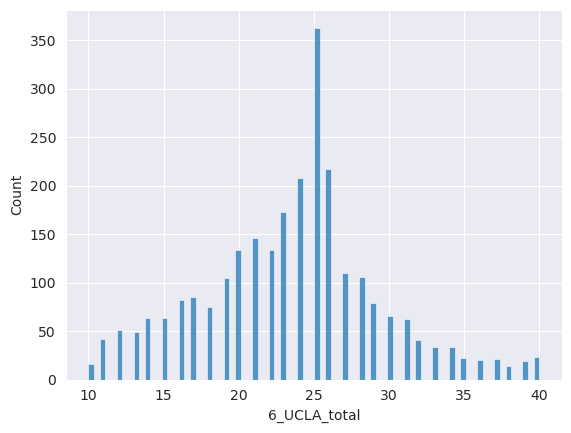

In [18]:
sns.histplot(dataset_cleaned['6_UCLA_total'], bins=80)
plt.show()

In [19]:
dataset_cleaned['6_UCLA_total'].describe()

count    2659.000000
mean       23.464460
std         5.988307
min        10.000000
25%        20.000000
50%        24.000000
75%        26.000000
max        40.000000
Name: 6_UCLA_total, dtype: float64

In [15]:
## K6 Dataset
# Declaring function for K6
def k6_condition(x):
    if 0 <= x <= 12:
        return 1 #'Unlikely distress'
    elif 13 <= x <= 24:
        return 2 #'Likely distress'

## PHQ9 Dataset
# Declaring function for PHQ-9
def phq9_condition(x):
    if 0 <= x <= 4:
        return 1 #'Minimal depression'
    elif 5 <= x <= 9:
        return 2 #'Mild'
    elif 10 <= x <= 14:
        return 3 #'Moderate'
    elif 15 <= x <= 19:
        return 4 #'Moderately severe'
    elif 20 <= x <= 27:
        return 5 #'Severe'

## SSS8 Dataset
# Declaring function for SSS-8
def sss8_condition(x):
    if 0 <= x <= 3:
        return 1 #'Minimal'
    elif 4 <= x <= 7:
        return 2 #'Low'
    elif 8 <= x <= 11:
        return 3 #'Medium'
    elif 12 <= x <= 15:
        return 4 #'High'
    elif 16 <= x <= 32:
        return 5 #'Very high'

## UCLA Dataset
# Declaring function for UCLA Loneliness Scale (UCLA LS)
def ucla_ls_condition(x):
    if 0 <= x <= 19:
        return 1 #'Minimal loneliness'
    elif 20 <= x <= 34:
        return 2 #'Low'
    elif 35 <= x <= 49:
        return 3 #'Moderate'
    elif 50 <= x <= 64:
        return 4 #'Moderately high'
    elif 65 <= x <= 80:
        return 5 #'High'

## LSNS6 Dataset
# Declaring function for LSNS-6
def lsns6_condition(x):
    if x == 0:
        return 1 #'Minimal social engagement'
    elif x == 60:
        return 2 #'High social engagement'
    else:
        return 3 #'Intermediate social engagement'


In [16]:
# Applying functions to transform column values
dataset_cleaned['6_K6_total'] = dataset_cleaned['6_K6_total'].apply(k6_condition)
dataset_cleaned['6_PHQ9_total'] = dataset_cleaned['6_PHQ9_total'].apply(phq9_condition)
dataset_cleaned['6_SSS8_total'] = dataset_cleaned['6_SSS8_total'].apply(sss8_condition)
dataset_cleaned['6_UCLA_total'] = dataset_cleaned['6_UCLA_total'].apply(ucla_ls_condition)
dataset_cleaned['6_LSNS6_total'] = dataset_cleaned['6_LSNS6_total'].apply(lsns6_condition)


In [17]:
dataset_cleaned.head(10)

,6_SEX,6_AGE,6_MARRIED,6_JOB,6_HINCOME,6_Exercise,6_HealthyDiet,6_HealthySleep,6_Interaction_offline,6_Interaction_online,...,6_Frustration,6_CovidAnxiety,6_CovidSleepless,6_DifficultyLiving,6_DifficultyWork,6_K6_total,6_PHQ9_total,6_SSS8_total,6_UCLA_total,6_LSNS6_total
4,1.0,57.0,2.0,4.0,4.0,5.0,4.0,4.0,4.0,4.0,...,3.0,5.0,5.0,5.0,5.0,1,4,5,2,3
8,2.0,70.0,2.0,8.0,7.0,1.0,6.0,7.0,4.0,5.0,...,1.0,5.0,1.0,1.0,6.0,1,1,1,1,3
11,1.0,52.0,1.0,3.0,3.0,2.0,3.0,5.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1,1,1,2,1
15,1.0,66.0,2.0,3.0,4.0,6.0,5.0,5.0,5.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1,1,1,2,3
19,1.0,63.0,2.0,2.0,7.0,1.0,2.0,5.0,5.0,3.0,...,4.0,4.0,2.0,4.0,4.0,1,1,1,2,3
21,1.0,62.0,1.0,4.0,3.0,1.0,4.0,6.0,1.0,1.0,...,4.0,4.0,4.0,4.0,4.0,1,1,2,2,3
22,1.0,69.0,2.0,9.0,3.0,7.0,6.0,7.0,6.0,1.0,...,2.0,2.0,2.0,2.0,2.0,1,1,2,2,3
24,1.0,53.0,1.0,7.0,10.0,1.0,4.0,5.0,2.0,1.0,...,4.0,4.0,1.0,1.0,4.0,1,2,3,2,3
27,1.0,46.0,1.0,11.0,4.0,2.0,4.0,7.0,7.0,1.0,...,5.0,4.0,4.0,4.0,4.0,1,1,3,2,3
31,1.0,55.0,1.0,3.0,4.0,5.0,5.0,3.0,5.0,4.0,...,4.0,6.0,2.0,4.0,3.0,1,1,3,2,3


In [18]:
len(dataset_cleaned)

2659

# Plots

In [20]:
# Descriptive statistics
dataset_cleaned.describe()

,6_SEX,6_AGE,6_MARRIED,6_JOB,6_HINCOME,6_Exercise,6_HealthyDiet,6_HealthySleep,6_Interaction_offline,6_Interaction_online,...,6_Frustration,6_CovidAnxiety,6_CovidSleepless,6_DifficultyLiving,6_DifficultyWork,6_K6_total,6_PHQ9_total,6_SSS8_total,6_UCLA_total,6_LSNS6_total
count,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,...,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000,2659.000000
mean,1.417074,56.038736,1.644603,6.670177,3.932681,3.820985,4.195562,4.607371,4.164724,2.810831,...,2.808199,2.633697,2.144415,2.189921,2.314404,1.071455,1.450169,1.857841,1.806694,2.785634
std,0.493168,12.700980,0.478723,3.293959,2.754909,1.969939,1.675332,1.705135,1.829843,1.805835,...,1.614478,1.538229,1.380634,1.426015,1.513317,0.257633,0.939507,1.189094,0.495518,0.618808
min,1.000000,22.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,48.000000,1.000000,4.000000,2.000000,2.000000,3.000000,4.000000,3.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,3.000000
50%,1.000000,56.000000,2.000000,6.000000,3.000000,4.000000,4.000000,5.000000,4.000000,3.000000,...,3.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,3.000000
75%,2.000000,65.000000,2.000000,9.000000,5.000000,5.000000,5.000000,6.000000,5.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,1.000000,1.000000,2.000000,2.000000,3.000000
max,2.000000,92.000000,2.000000,12.000000,10.000000,7.000000,7.000000,7.000000,7.000000,7.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,2.000000,5.000000,5.000000,3.000000,3.000000


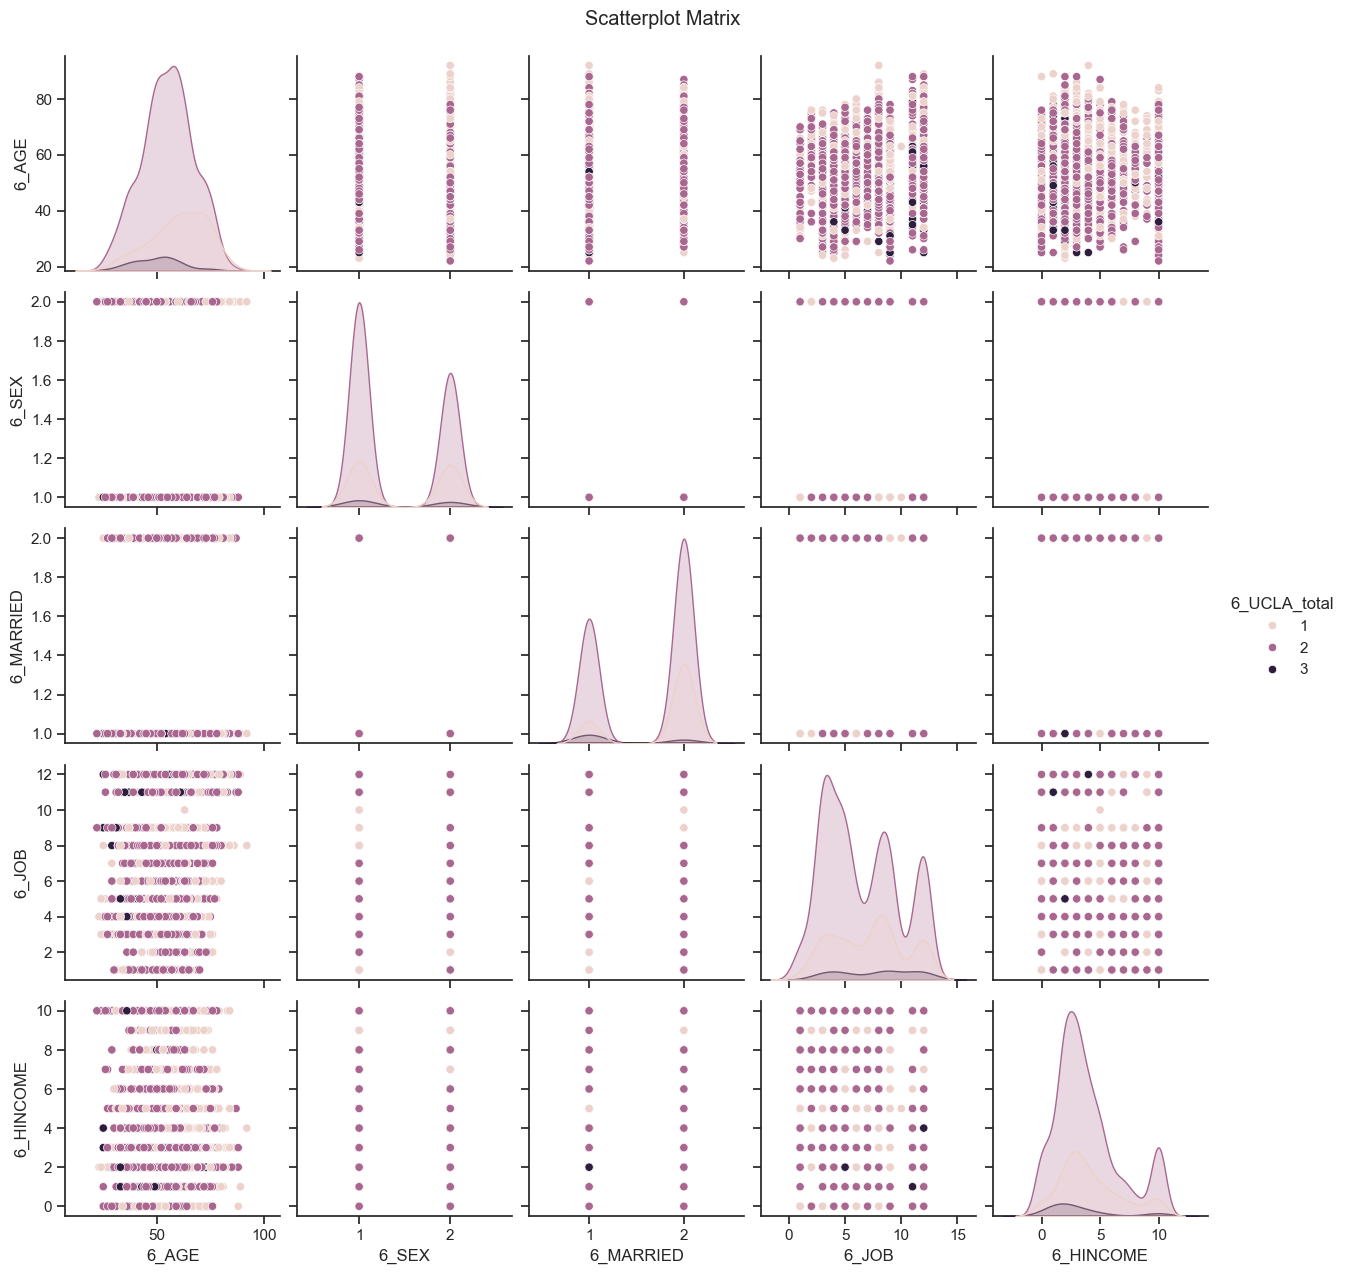

In [21]:
# https://seaborn.pydata.org/examples/scatterplot_matrix.html
# Scatterplot Matrix
sns.set_theme(style="ticks")
scatterplot_columns = ['6_AGE', '6_SEX', '6_MARRIED', '6_JOB', '6_HINCOME', '6_UCLA_total']
sns.pairplot(dataset_cleaned[scatterplot_columns], hue="6_UCLA_total")
plt.suptitle("Scatterplot Matrix", y=1.02)
plt.show()

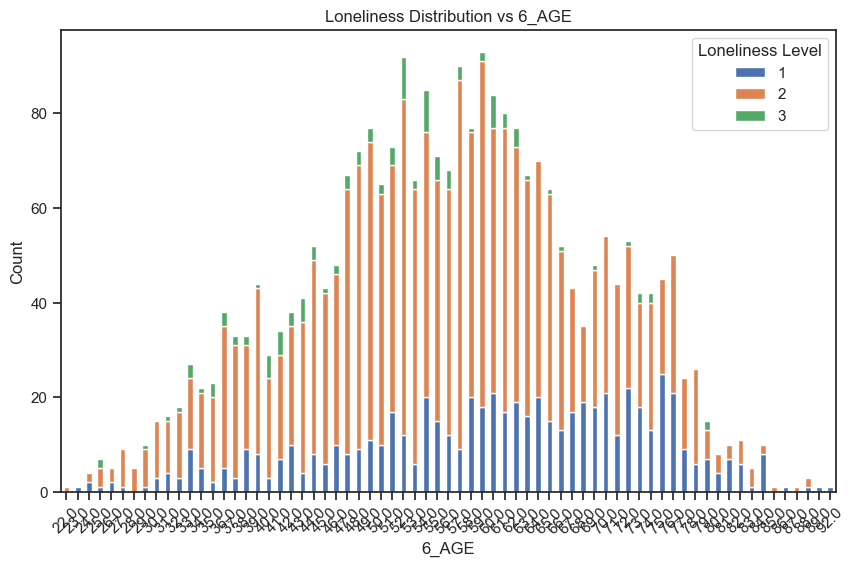

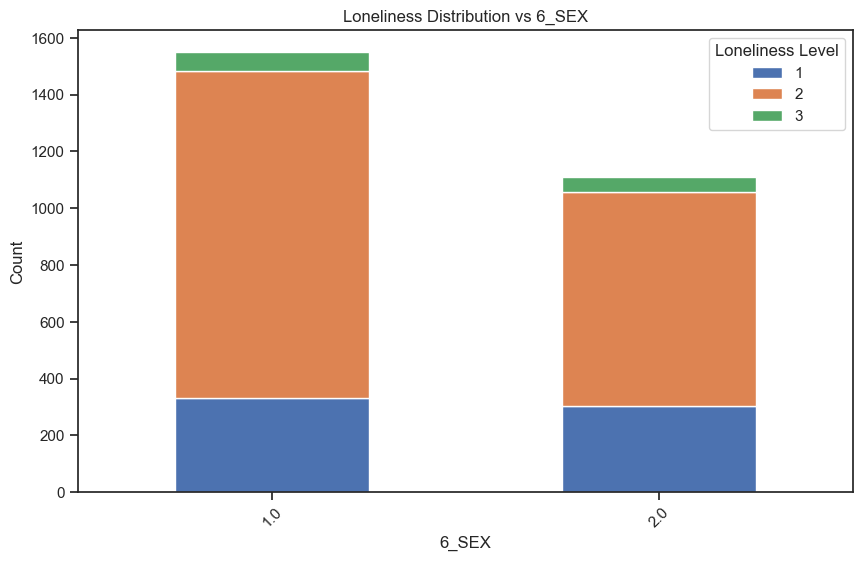

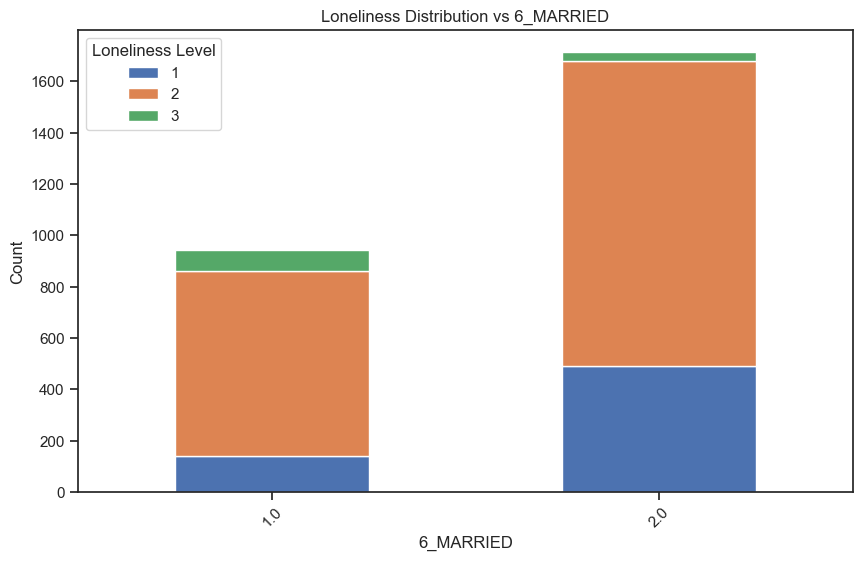

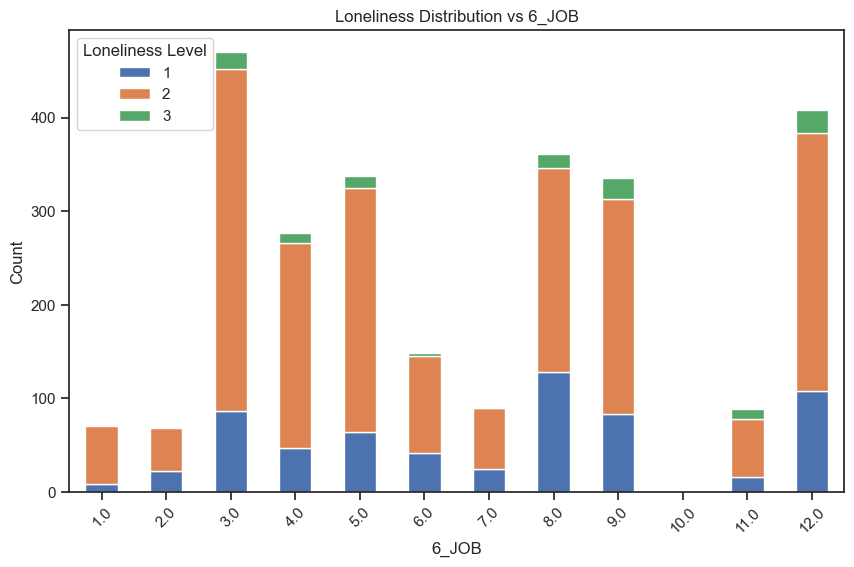

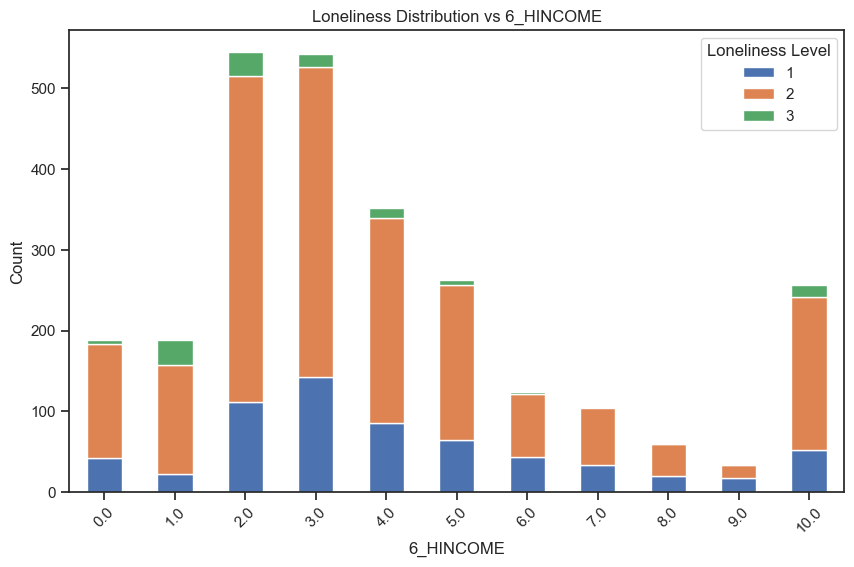

In [22]:
# https://www.geeksforgeeks.org/create-a-stacked-bar-plot-in-matplotlib/
demographic_vars = ['6_AGE', '6_SEX', '6_MARRIED', '6_JOB', '6_HINCOME']
loneliness_var = '6_UCLA_total'

for var in demographic_vars:
    stacked_data = dataset_cleaned.groupby([var, loneliness_var]).size().unstack(fill_value=0)
    
    stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), title=f'Loneliness Distribution vs {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.legend(title='Loneliness Level')
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# convert to plotly

# swarm plot for regression
# pick n mix plots

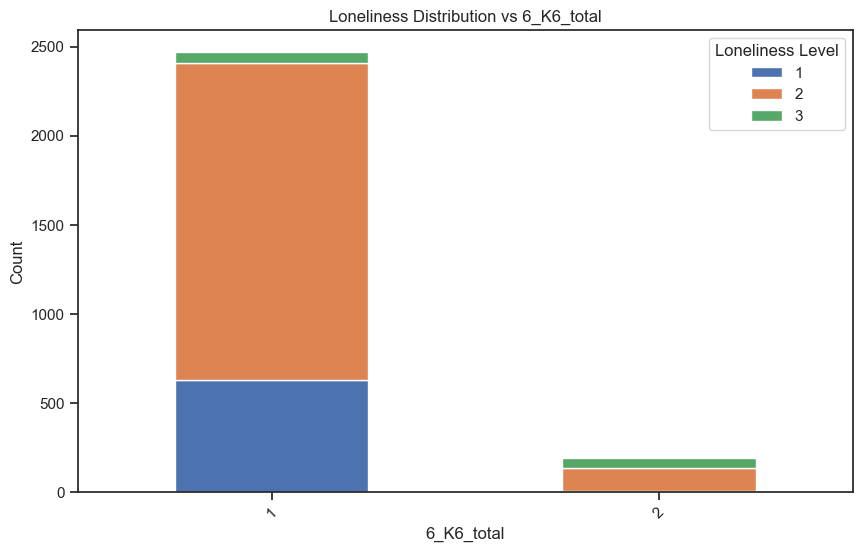

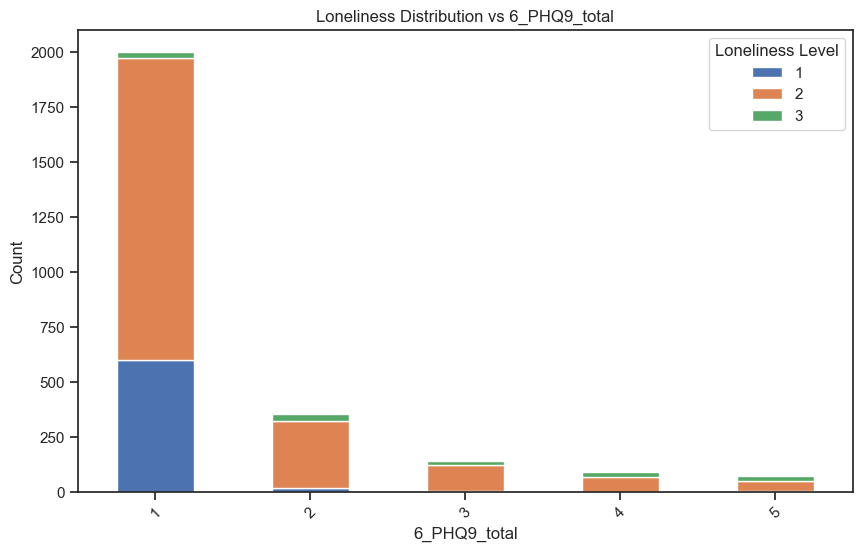

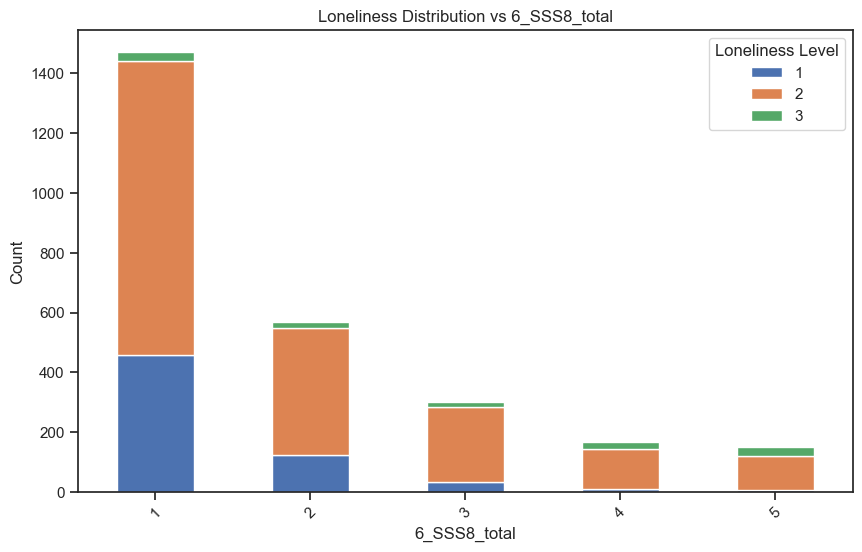

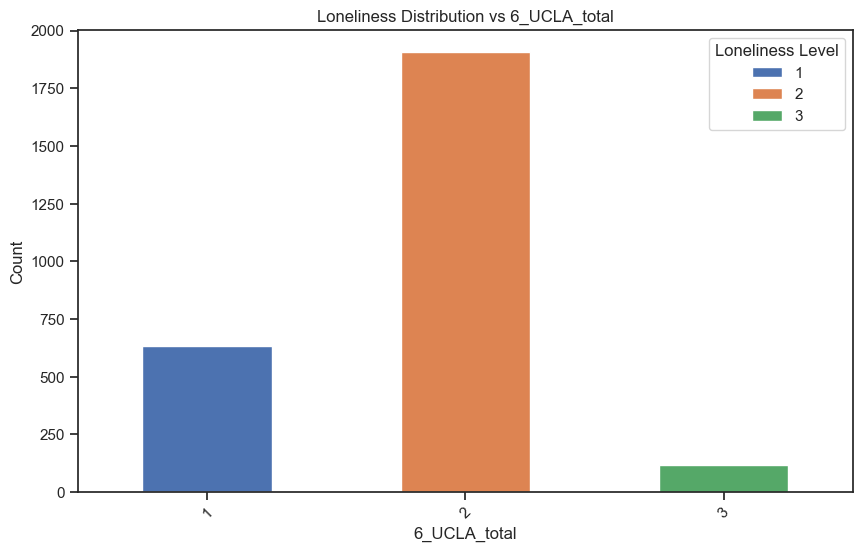

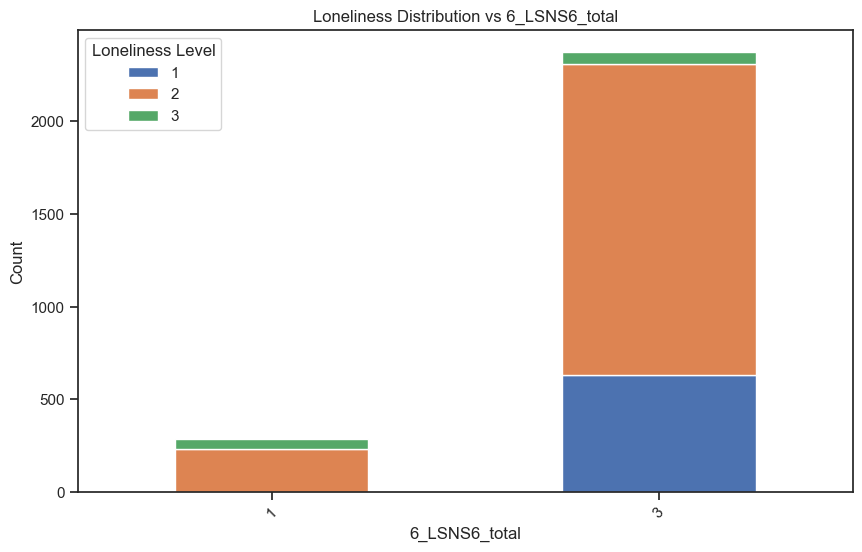

In [23]:
psych_vars = ['6_K6_total', '6_PHQ9_total', '6_SSS8_total', '6_UCLA_total', '6_LSNS6_total']
loneliness_var = '6_UCLA_total'

for var in psych_vars:
    stacked_data = dataset_cleaned.groupby([var, loneliness_var]).size().unstack(fill_value=0)
    
    stacked_data.plot(kind='bar', stacked=True, figsize=(10, 6), title=f'Loneliness Distribution vs {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.legend(title='Loneliness Level')
    plt.xticks(rotation=45)
    plt.show()

In [24]:
# One-Hot Encoding for categorical variables

categorical_columns = [
 '6_SEX',
 '6_MARRIED',
 '6_JOB',]
dataset_encoded = pd.get_dummies(dataset_cleaned, columns=categorical_columns, drop_first=True)
dataset_encoded.head()

,6_AGE,6_HINCOME,6_Exercise,6_HealthyDiet,6_HealthySleep,6_Interaction_offline,6_Interaction_online,6_DeteriorationEconomy,6_DeteriorationInteract,6_Frustration,...,6_JOB_3.0,6_JOB_4.0,6_JOB_5.0,6_JOB_6.0,6_JOB_7.0,6_JOB_8.0,6_JOB_9.0,6_JOB_10.0,6_JOB_11.0,6_JOB_12.0
4,57.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0,3.0,3.0,...,False,True,False,False,False,False,False,False,False,False
8,70.0,7.0,1.0,6.0,7.0,4.0,5.0,1.0,1.0,1.0,...,False,False,False,False,False,True,False,False,False,False
11,52.0,3.0,2.0,3.0,5.0,1.0,1.0,4.0,1.0,1.0,...,True,False,False,False,False,False,False,False,False,False
15,66.0,4.0,6.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,...,True,False,False,False,False,False,False,False,False,False
19,63.0,7.0,1.0,2.0,5.0,5.0,3.0,4.0,4.0,4.0,...,False,False,False,False,False,False,False,False,False,False


# Splitting datasets

In [25]:
# -------------------------------------
# Library configuration
# -------------------------------------

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [26]:
# Extract the target and features
y = dataset_encoded['6_UCLA_total']
X = dataset_encoded.drop(columns=['6_UCLA_total'])

# Encode the labels
encoder = LabelEncoder()
encoded_label = encoder.fit_transform(y)

# Reflect encoder changes in y
y_encoded = encoder.transform(y)

#Get the training and test set from the K6 dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state= 30)

# Calculate the count of each unique label
unique_labels, label_counts = np.unique(y_test, return_counts=True)

In [27]:
labels = []

print("Test data distribution")
for label, count in zip(unique_labels, label_counts):
    label_name = encoder.inverse_transform([label])[0]
    labels.append(label_name)
    print(f"Label: {label_name}, Count: {count}")

Test data distribution
Label: 1, Count: 181
Label: 2, Count: 572
Label: 3, Count: 45


# Model Training

In [28]:
# -------------------------------------
# Library configuration
# -------------------------------------

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, \
    f1_score

from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [29]:
# Define a function to train and predict using a given model
def train_and_predict(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return predictions

# Define a function to evaluate the model's predictions
def evaluate_model(y_test, predictions):
    accuracy = accuracy_score(y_test, predictions) * 100
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100
    f1 = f1_score(y_test, predictions, average='macro') * 100
    return accuracy, precision, recall, f1


# Define a function to print evaluation metrics
def print_evaluation_metrics(accuracy, precision, recall, f1):
    print(f"Accuracy: {accuracy:.10f}")
    print(f"Precision: {precision:.10f}")
    print(f"Recall: {recall:.10f}")
    print(f"F1-score: {f1:.10f}")

# List of models to test
models = [
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("K-Nearest Neighbors", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Gaussian Naive Bayes", GaussianNB()),
    ("Support Vector Machine", SVC(random_state=random_state)),
    ("MLP Classifier", MLPClassifier(random_state=random_state))
]

In [30]:
for model_name, model in models:
    print(f"\n  Model: {model_name}")
    predictions = train_and_predict(model, X_train, y_train, X_test)
    accuracy, precision, recall, f1 = evaluate_model(y_test, predictions)
    print_evaluation_metrics(accuracy, precision, recall, f1)


  Model: Random Forest
Accuracy: 75.6892230576
Precision: 71.8471810089
Recall: 46.6870575710
F1-score: 48.8363205225

  Model: K-Nearest Neighbors
Accuracy: 72.8070175439
Precision: 65.5585517019
Recall: 46.5327449305
F1-score: 48.4623686216

  Model: Decision Tree
Accuracy: 66.0401002506
Precision: 47.9063686510
Recall: 47.1758812090
F1-score: 47.4181844708

  Model: Gaussian Naive Bayes
Accuracy: 44.3609022556
Precision: 48.9649501251
Recall: 67.1887095920
F1-score: 41.9223806643

  Model: Support Vector Machine
Accuracy: 74.0601503759
Precision: 50.3538663172
Recall: 37.8395085577
F1-score: 36.4981273408

  Model: MLP Classifier
Accuracy: 75.3132832080
Precision: 67.7232861281
Recall: 46.9563033651
F1-score: 50.5411351536


In [31]:
best_model = RandomForestClassifier(random_state=random_state)
best_model.fit(X_train, y_train)

RandomForestClassifier(random_state=8)

In [32]:
predictions = best_model.predict(X_test)

[[ 75 106   0]
 [ 45 526   1]
 [  0  42   3]]


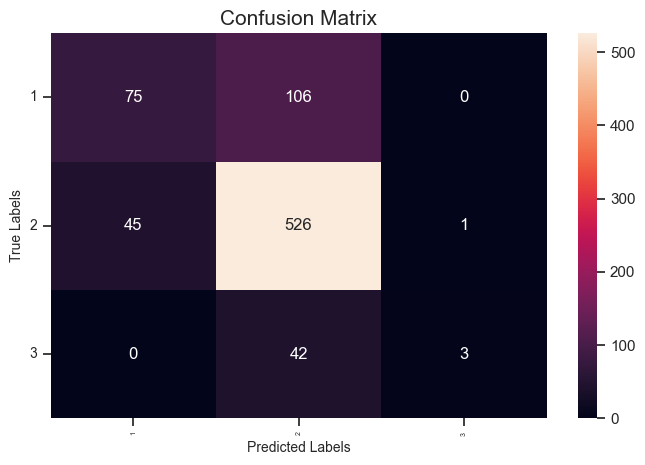

In [33]:
#Confusion matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

#Plot the Confusion matrix graph
fig = plt.figure(figsize=(8, 5))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g')
ax.set_xlabel('Predicted Labels', fontsize=10)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(labels, fontsize=5)
ax.xaxis.tick_bottom()

ax.set_ylabel('True Labels', fontsize=10)
ax.yaxis.set_ticklabels(labels, fontsize=10)
plt.yticks(rotation=0)

plt.title('Confusion Matrix', fontsize=15)

plt.show()

In [34]:
# Evaluate the model using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='macro')
recall = recall_score(y_test, predictions, average='macro')
f1 = f1_score(y_test, predictions, average='macro')


# Print the evaluation metrics
print("Accuracy: %.f" %(accuracy*100))
print("Precision: %.f" %(precision*100))
print("Recall: %.f" %(recall*100))
print("F1-score: %.f" %(f1*100))

Accuracy: 76
Precision: 72
Recall: 47
F1-score: 49


## Hyperparameter Tuning

In [35]:
import pprint
import joblib as job
import time

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import sklearn.metrics as metrics

pp = pprint.PrettyPrinter(indent=1)

In [36]:
# Define hyperparameter space
n_estimators = [100, 250, 500, 1000]                       # Range of trees
max_features = ['sqrt', 'log2']                 # Feature selection
max_depth = [int(x) for x in np.linspace(10, 100, num=10)]
max_depth.append(None) # Depth
min_samples_split = [2, 5, 10, 15]                     # Control overfitting
min_samples_leaf = [1, 2, 4, 6]                       # Prevent overfitting
bootstrap = [True, False]                              # Sampling strategy
class_weight = ['balanced', None]               # Handling of imbalanced classes
cv = 10                                         # Cross-validation folds

# Create the random grid
random_grid = {
    'n_estimators': n_estimators,
    'max_features': max_features,
    'max_depth': max_depth,
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf,
    'bootstrap': bootstrap,
    'class_weight': class_weight
}

print('Hyperparameter search space:')
pp.pprint(random_grid)

# Set the hyperparameter tuner
start_time = time.time()
model = RandomForestClassifier(random_state=random_state, verbose=0)

# Randomized Search CV
print("\nStarting Randomized Search CV...")
tuner = RandomizedSearchCV(estimator=model, 
                           param_distributions=random_grid, 
                           n_iter=200, 
                           cv=10, 
                           scoring='r2', 
                           random_state=random_state, 
                           verbose=1, 
                           return_train_score=True, 
                           n_jobs=10)

# Fit the random search model
print("Fitting the Randomized Search model...")
tuner.fit(X_train, y_train)
print("Randomized Search CV completed.")

# Time taken for Randomized Search
end_time = time.time()
running_time = end_time - start_time
print('\nRandom Forest training time:', running_time, 's')

# Now, if you want to continue with Grid Search
print("\nStarting Grid Search CV...")
tuner_grid = GridSearchCV(estimator=model, 
                          param_grid=random_grid, 
                          cv=cv, 
                          scoring='r2', 
                          verbose=6, 
                          return_train_score=True, 
                          n_jobs=10)

# Fit the grid search model
print("Fitting the Grid Search model...")
tuner_grid.fit(X_train, y_train)
print("Grid Search CV completed.")

# Time taken for Grid Search
end_time_grid = time.time()
running_time_grid = end_time_grid - end_time
print('\nGrid Search training time:', running_time_grid, 's')

Hyperparameter search space:
{'bootstrap': [True, False],
 'class_weight': ['balanced', None],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
 'max_features': ['sqrt', 'log2'],
 'min_samples_leaf': [1, 2, 4, 6],
 'min_samples_split': [2, 5, 10, 15],
 'n_estimators': [100, 250, 500, 1000]}

Starting Randomized Search CV...
Fitting the Randomized Search model...
Fitting 10 folds for each of 200 candidates, totalling 2000 fits
Randomized Search CV completed.

Random Forest training time: 235.74080300331116 s

Starting Grid Search CV...
Fitting the Grid Search model...
Fitting 10 folds for each of 5632 candidates, totalling 56320 fits
Grid Search CV completed.

Grid Search training time: 6743.437982082367 s


In [37]:
# Save the model
model_name = type(tuner).__name__
file_name = model_name + '_' + time.strftime("%Y%m%d-%H%M%S") + '.mod'
file_save = file_name

print('Saving', model_name, 'model as', file_name, '...')
job.dump(tuner, file_save) 

Saving RandomizedSearchCV model as RandomizedSearchCV_20250210-005452.mod ...


['RandomizedSearchCV_20250210-005452.mod']

In [38]:
# Load the model
file_model = 'RandomizedSearchCV_20250210-005452.mod'
file_load = file_model

saved_model = job.load(file_load) 
tuner = saved_model

print('Best hyperparameters:')
pp.pprint(tuner.best_estimator_.get_params())

Best hyperparameters:
{'bootstrap': False,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 1000,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 8,
 'verbose': 0,
 'warm_start': False}


In [39]:
# Check the tuned model
print('Best hyperparameters:')
print(tuner.best_estimator_)

Best hyperparameters:
RandomForestClassifier(bootstrap=False, max_depth=10, min_samples_split=5,
                       n_estimators=1000, random_state=8)


## Cross-validation Results

{'n_estimators': [100, 250, 500, 1000], 'max_features': ['sqrt', 'log2'], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None], 'min_samples_split': [2, 5, 10, 15], 'min_samples_leaf': [1, 2, 4, 6], 'bootstrap': [True, False], 'class_weight': ['balanced', None]}
n_estimators = 100 : -0.005734468395327574
n_estimators = 250 : 0.022050775106882595
n_estimators = 500 : 0.008456768270127497
n_estimators = 1000 : 0.011004145028771012
max_features = sqrt : 0.019675576682140757
max_features = log2 : -0.004682477161630797
max_depth = 10 : -0.003279507844864167
max_depth = 20 : 0.006158366851538789
max_depth = 30 : -0.005522507806042727
max_depth = 40 : -0.004134785969452117
max_depth = 50 : -0.003836771881868261
max_depth = 60 : -0.01821505643553915
max_depth = 70 : 0.003224610586812271
max_depth = 80 : 0.020697283067842007
max_depth = 90 : 0.026043677361024753
max_depth = 100 : 0.01216604704210739
max_depth = None : 0.029255513932763915
min_samples_split = 2 : 0.014688771680959669
min

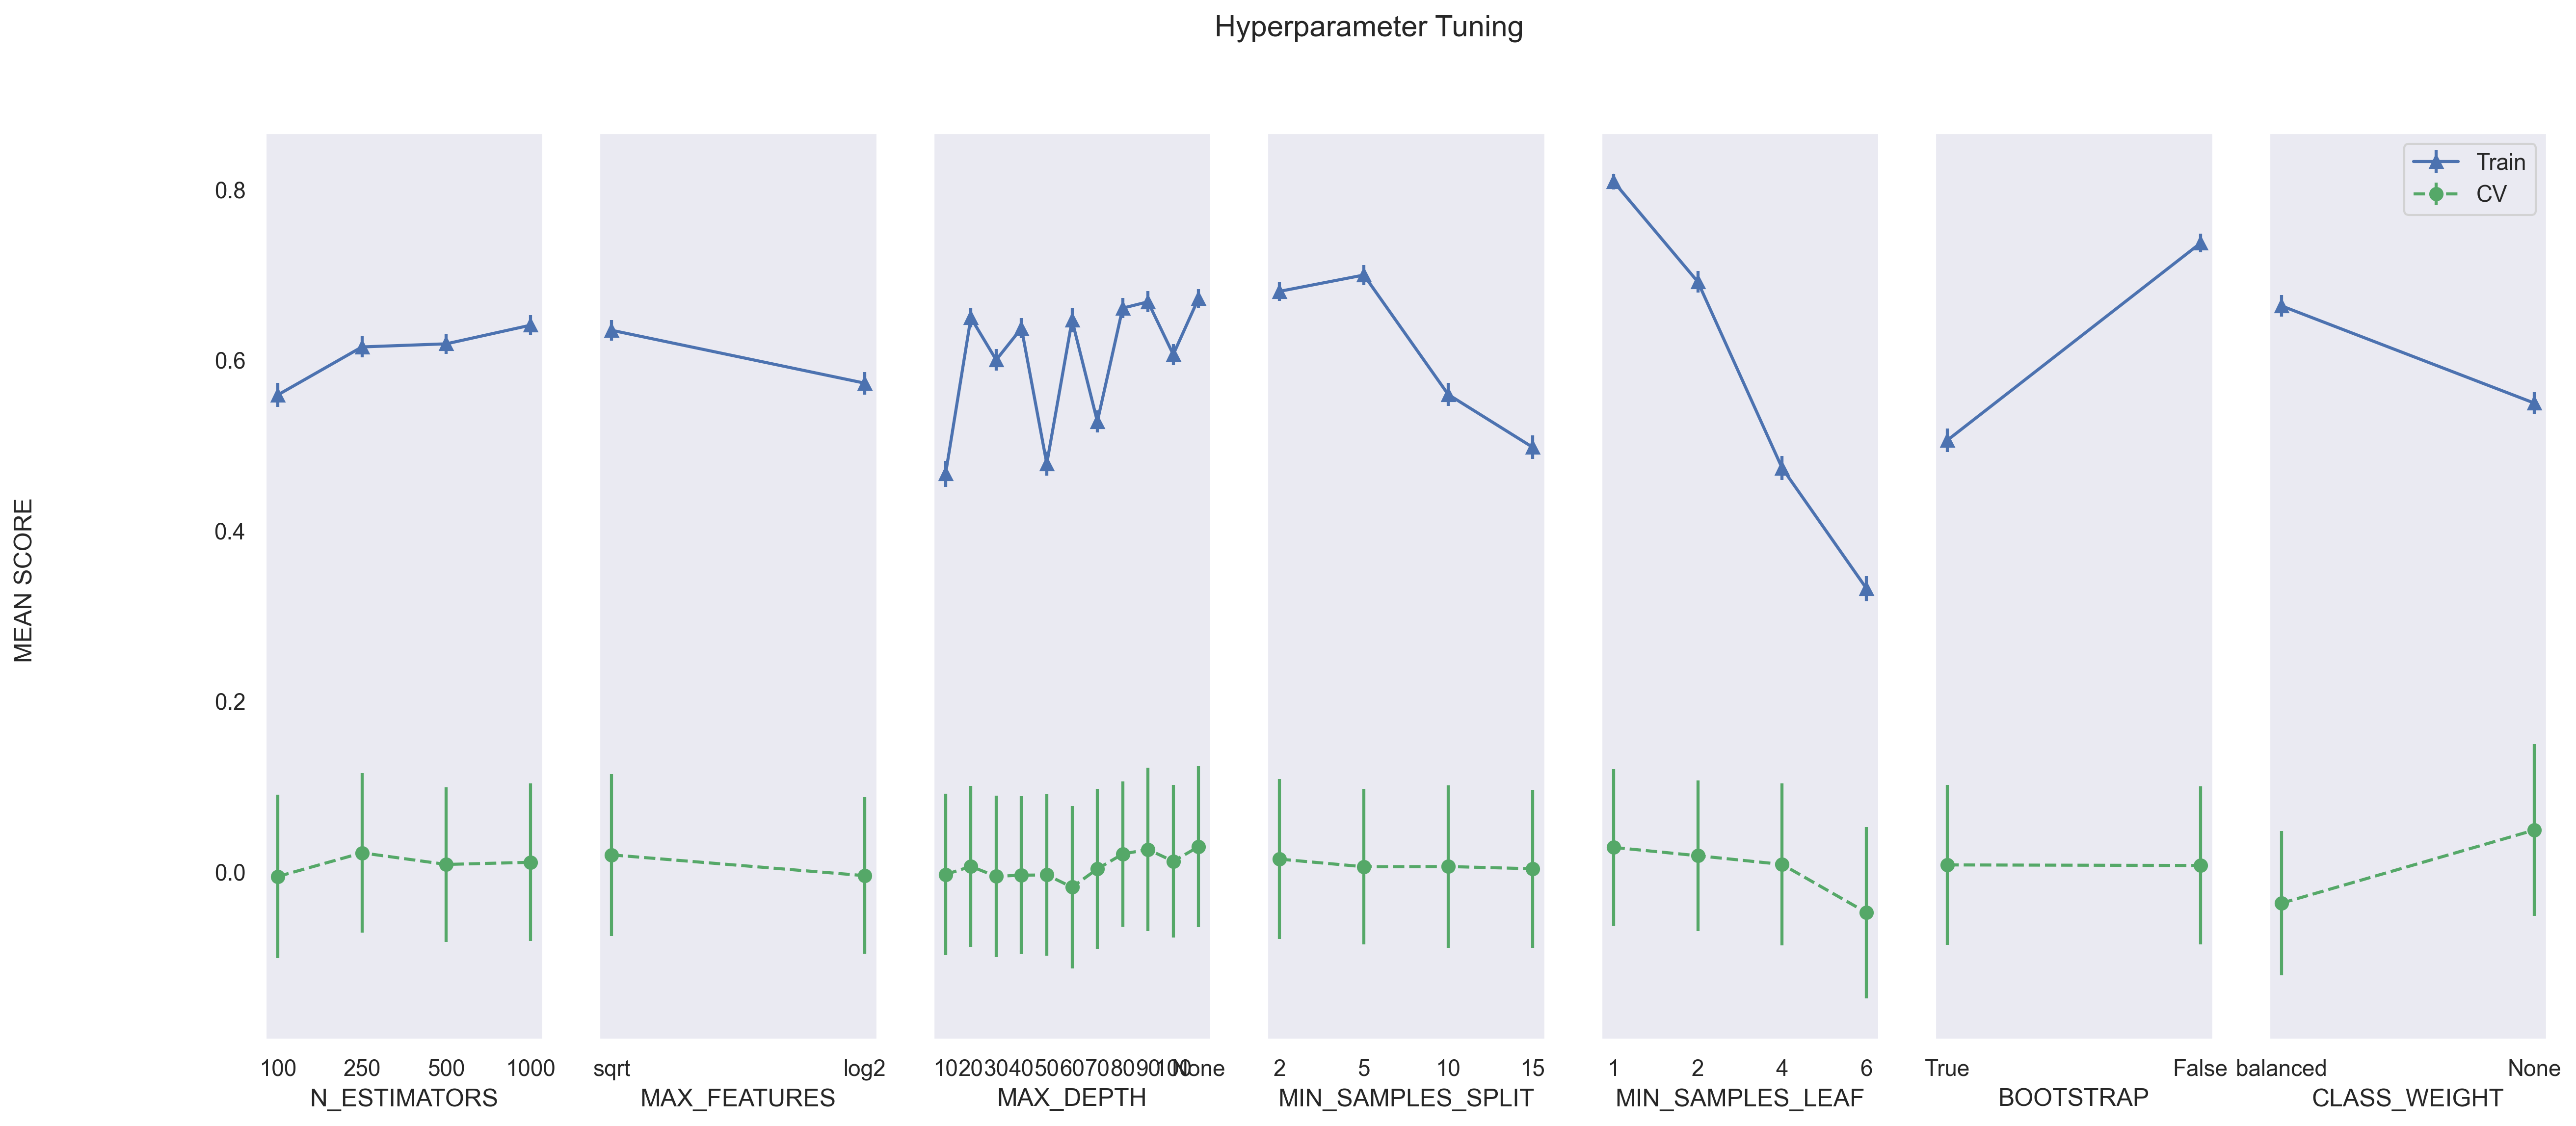

{'mean_fit_time': array([0.55189879, 0.25033317, 1.2347996 , 0.20336132, 0.20664837,
       0.50774896, 0.22944748, 0.19247057, 1.09504285, 0.21283712,
       0.24438798, 0.53953426, 0.19445148, 0.26156254, 1.56287282,
       0.77387173, 0.42987814, 1.20569339, 2.09585094, 1.07439251,
       0.21047916, 2.76564047, 2.43336425, 1.046243  , 0.5043155 ,
       0.63316922, 0.60580409, 2.92017798, 1.02792497, 1.04321365,
       0.23037684, 2.97968216, 1.2815964 , 0.22371275, 0.59889965,
       0.8927866 , 0.24071801, 0.23480937, 0.4930758 , 2.6838655 ,
       0.23354785, 1.09655709, 0.20294631, 2.82355342, 0.24338269,
       0.27436788, 0.27515759, 0.70737121, 0.27582331, 1.20053549,
       2.1321419 , 1.32386227, 0.27584176, 1.14735515, 2.01666842,
       1.6891474 , 3.08562124, 0.24082165, 2.66231427, 2.34256835,
       2.40189569, 0.22718859, 0.24981949, 1.15760944, 0.60856652,
       2.03549931, 1.03793797, 1.19851489, 0.20315149, 1.9767401 ,
       0.24139423, 2.5294842 , 0.21121509, 0

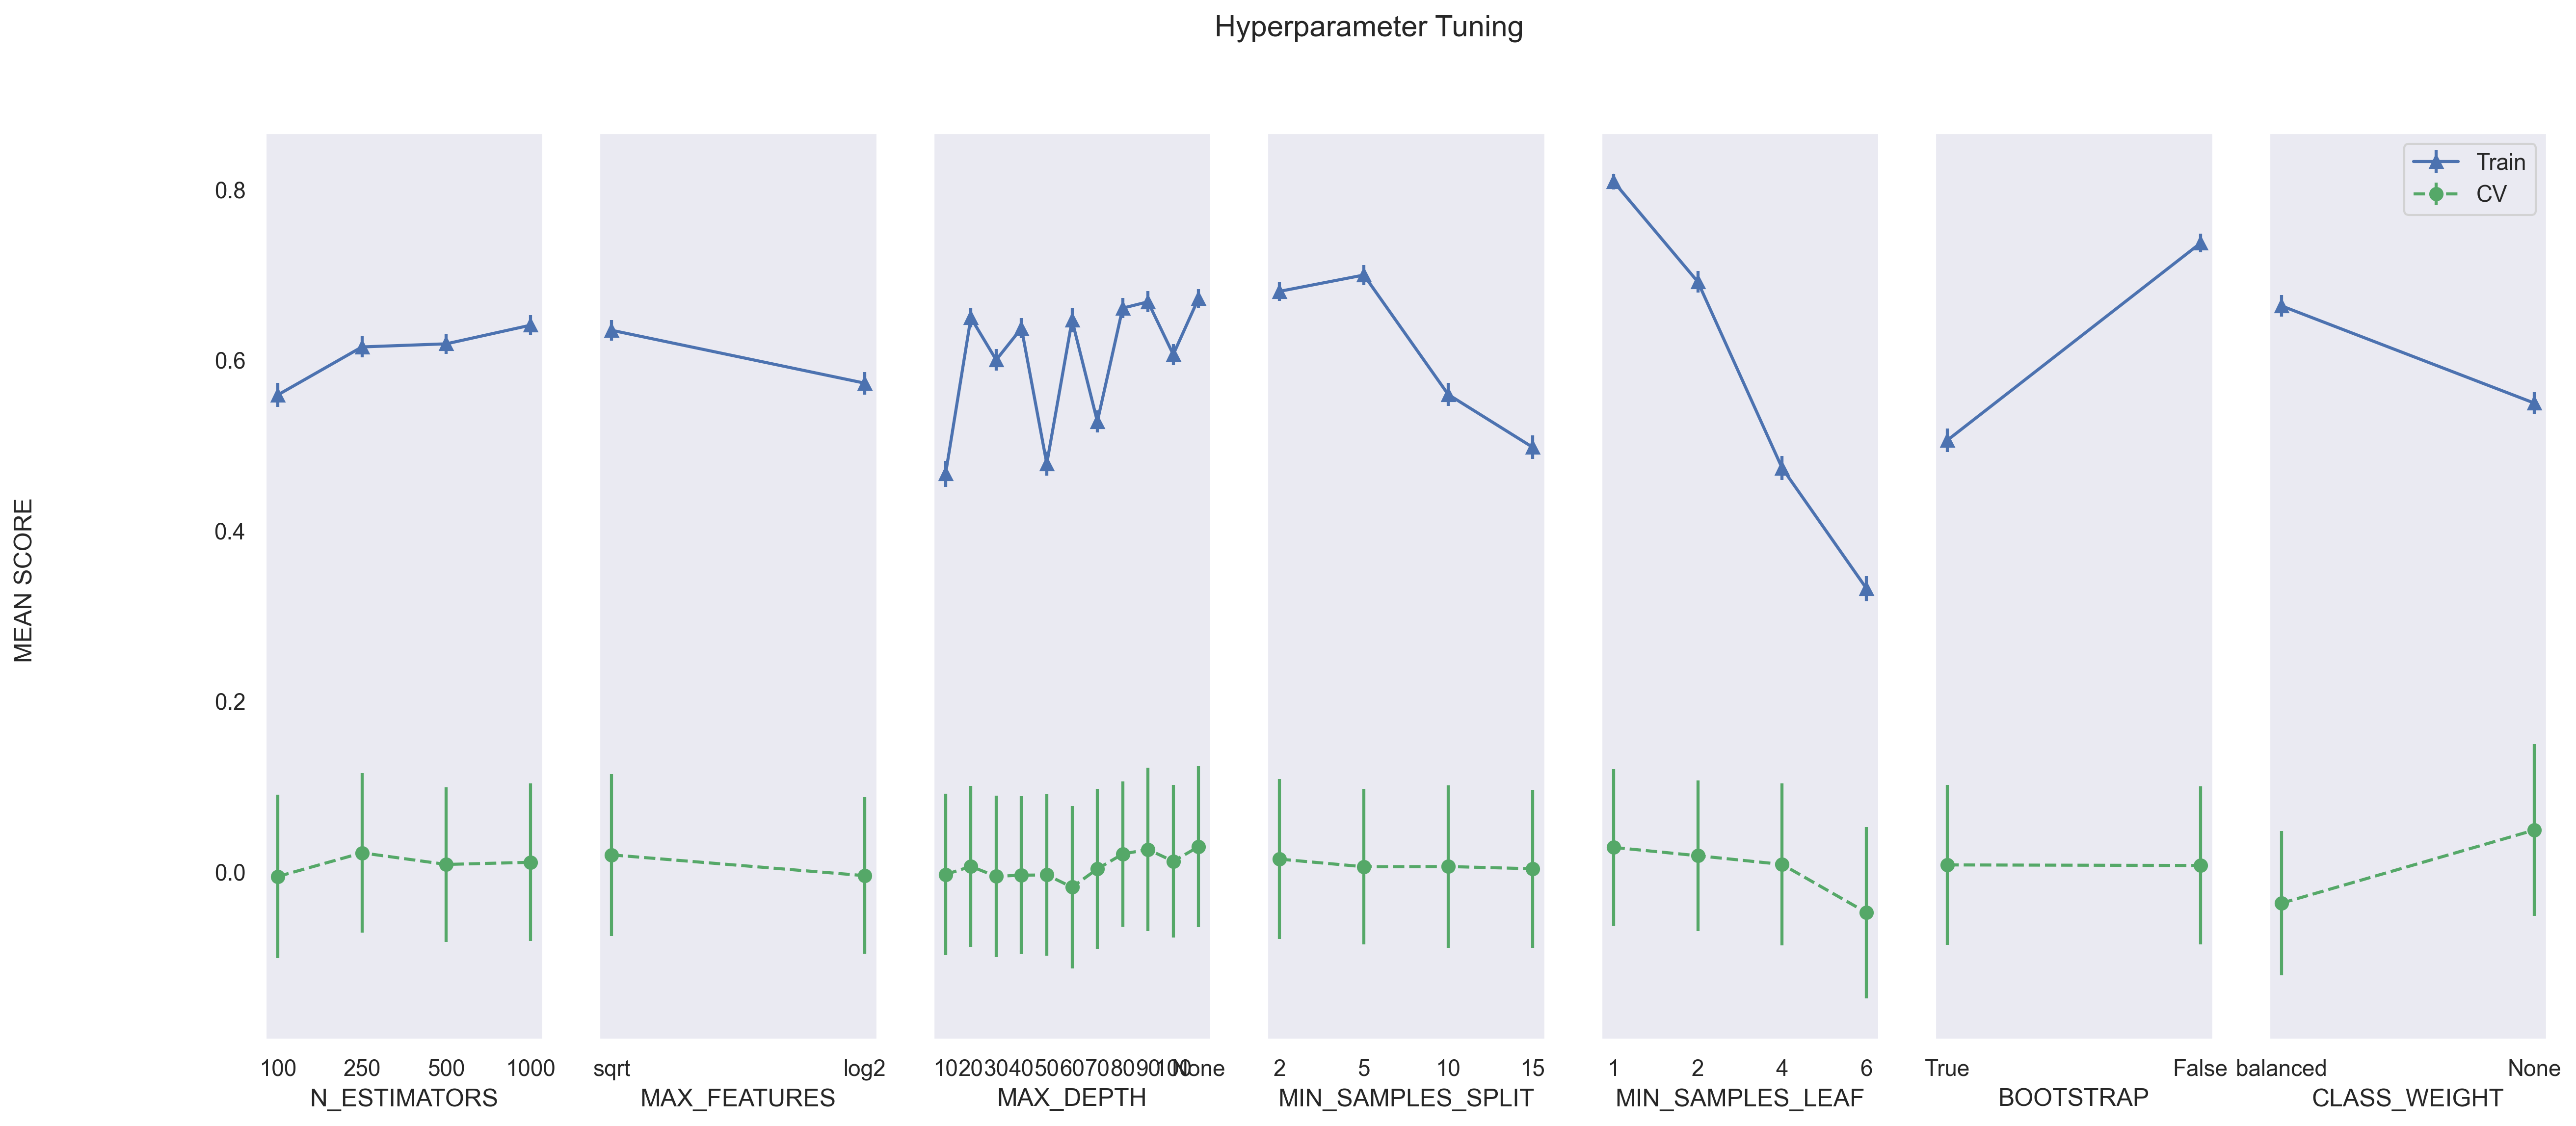

In [40]:
## Plot CV results
def plot_cv(tuner):
    results = tuner.cv_results_
    cv_params = tuner.param_distributions
    means_test = results['mean_test_score']
    stds_test = results['std_test_score']
    means_train = results['mean_train_score']
    stds_train = results['std_train_score']

    print(cv_params)
    fig, ax = plt.subplots(1, len(cv_params), sharex='none', sharey='all', figsize=(20,8), dpi=300)
    fig.suptitle('Hyperparameter Tuning')
    fig.text(0.04, 0.5, 'MEAN SCORE', va='center', rotation='vertical')

    scores = {}
    for i, (param, param_val) in enumerate(cv_params.items()):
        x, y1, e1, y2, e2 = [], [], [], [], []

        for v in param_val:
            mask_idx = results['param_'+param]==v
            v = str(v)

            m_train = np.mean(means_train[mask_idx])
            s_train = np.sqrt(np.mean(stds_train[mask_idx]**2))
            m_test = np.mean(means_test[mask_idx])    
            s_test = np.sqrt(np.mean(stds_test[mask_idx]**2))

            scores[param+'='+v+'_means_train'] = m_train
            scores[param+'='+v+'_stds_train'] = s_train    
            scores[param+'='+v+'_means_test'] = m_test
            scores[param+'='+v+'_stds_test'] = s_test
            print(param, "=", v, ":", m_test)

            x.append(v)
            y1.append(m_train)
            e1.append(s_train) 
            y2.append(m_test) 
            e2.append(s_test)

        ax[i].errorbar(x, y1, e1, linestyle='-', marker='^', label='Train')
        ax[i].errorbar(x, y2, e2, linestyle='--', marker='o', color='g', label='CV')
        ax[i].set_xlabel(param.upper())

    # pp.pprint(scores)

    plt.legend()
    plt.show()

sns.set_style('dark')
plot_cv(tuner)
print(tuner.cv_results_)
plot_cv(saved_model)

In [41]:
## Evaluate model
def evaluate(model, X, y_actual):
    y_predicted = model.predict(X)
    mae = metrics.mean_absolute_error(y_actual, y_predicted)
    mse = metrics.mean_squared_error(y_actual, y_predicted)
    rmse = np.sqrt(mse)
    re = np.divide(np.abs(y_actual - y_predicted), y_actual) * 100
    mre = np.mean(re)
    r2 = model.score(X, y_actual)

    print('Model Performance')
    print('MAE: {:0.4f}'.format(mae))
    print('MSE: {:0.4f}'.format(mse))
    print('RMSE: {:0.4f}'.format(rmse))
    print('MRE: {:0.4f}%'.format(mre))
    print('R2: {:0.4f}'.format(r2))
    
    return r2

print('Base model')
base_model = RandomForestClassifier(random_state=random_state)
base_model.fit(X_train, y_train)
base_accuracy = evaluate(base_model, X_test, y_test)

print('\nTuned model')
tuned_model = tuner.best_estimator_
tuned_accuracy = evaluate(tuned_model, X_test, y_test)

print('\nSaved model')
saved_accuracy = evaluate(saved_model.best_estimator_, X_test, y_test)

print('\nImprovement: {:0.2f}'.format(tuned_accuracy - base_accuracy))

Base model
Model Performance
MAE: 0.2431
MSE: 0.2431
RMSE: 0.4931
MRE: nan%
R2: 0.7569

Tuned model
Model Performance
MAE: 0.2368
MSE: 0.2368
RMSE: 0.4867
MRE: nan%
R2: 0.7632

Saved model
Model Performance
MAE: 0.2368
MSE: 0.2368
RMSE: 0.4867
MRE: nan%
R2: 0.7632

Improvement: 0.01


In [42]:
predictions = tuned_model.predict(X_test)

[[ 75 106   0]
 [ 41 530   1]
 [  0  41   4]]


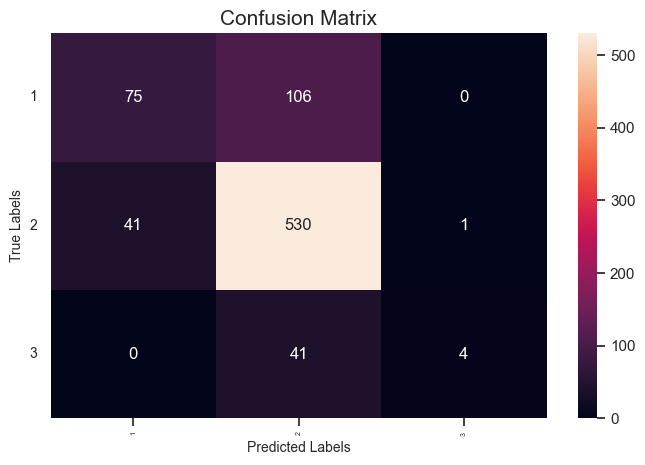

In [43]:
#Confusion matrix
cm = confusion_matrix(y_test, predictions)
print(cm)

#Plot the Confusion matrix graph
fig = plt.figure(figsize=(8, 5))
ax = plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, fmt='g')
ax.set_xlabel('Predicted Labels', fontsize=10)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(labels, fontsize=5)
ax.xaxis.tick_bottom()

ax.set_ylabel('True Labels', fontsize=10)
ax.yaxis.set_ticklabels(labels, fontsize=10)
plt.yticks(rotation=0)

plt.title('Confusion Matrix', fontsize=15)

plt.show()

In [45]:
# Evaluate the model using accuracy, precision, recall, and F1-score
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average='macro')
recall = recall_score(y_test, predictions, average='macro')
f1 = f1_score(y_test, predictions, average='macro')


# Print the evaluation metrics
print("Accuracy: %.f" %(accuracy*100))
print("Precision: %.f" %(precision*100))
print("Recall: %.f" %(recall*100))
print("F1-score: %.f" %(f1*100))

Accuracy: 76
Precision: 74
Recall: 48
F1-score: 50


# Model Expalanation

In [50]:
import shap
import pickle

In [52]:
# Calculate SHAP
explainer = shap.TreeExplainer(tuned_model)

In [53]:
shap_values = explainer.shap_values(X_train)
shap_test_values = explainer.shap_values(X_test)

In [54]:
# Define paths for saving
explainer_path = "explainer.pkl"
shap_values_train_path = "shap_values_train.pkl"
shap_values_test_path = "shap_values_test.pkl"

In [55]:
# Save the explainer
with open(explainer_path, "wb") as f:
    pickle.dump(explainer, f)

# Save the SHAP values for training and test data
with open(shap_values_train_path, "wb") as f:
    pickle.dump(shap_values, f)

with open(shap_values_test_path, "wb") as f:
    pickle.dump(shap_test_values, f)

In [56]:
# Load the explainer
with open(explainer_path, "rb") as f:
    explainer = pickle.load(f)

# Load the SHAP values for training and test data
with open(shap_values_train_path, "rb") as f:
    shap_values = pickle.load(f)

with open(shap_values_test_path, "rb") as f:
    shap_test_values = pickle.load(f)


## Feature Importance

In [57]:
# Creating features list
features_list = dataset_encoded.drop(columns=['6_UCLA_total']).columns.tolist()
features_list

['6_AGE',
 '6_HINCOME',
 '6_Exercise',
 '6_HealthyDiet',
 '6_HealthySleep',
 '6_Interaction_offline',
 '6_Interaction_online',
 '6_DeteriorationEconomy',
 '6_DeteriorationInteract',
 '6_Frustration',
 '6_CovidAnxiety',
 '6_CovidSleepless',
 '6_DifficultyLiving',
 '6_DifficultyWork',
 '6_K6_total',
 '6_PHQ9_total',
 '6_SSS8_total',
 '6_LSNS6_total',
 '6_SEX_2.0',
 '6_MARRIED_2.0',
 '6_JOB_2.0',
 '6_JOB_3.0',
 '6_JOB_4.0',
 '6_JOB_5.0',
 '6_JOB_6.0',
 '6_JOB_7.0',
 '6_JOB_8.0',
 '6_JOB_9.0',
 '6_JOB_10.0',
 '6_JOB_11.0',
 '6_JOB_12.0']

In [58]:
# specifying class names
ucla_class_mapping = {
    1: 'Minimal loneliness',
    2: 'Low',
    3: 'Moderate',
    4: 'Moderately high',
    5: 'High'
}
class_names = [ucla_class_mapping[i] for i in sorted(ucla_class_mapping.keys())]

print(class_names)

['Minimal loneliness', 'Low', 'Moderate', 'Moderately high', 'High']


SHAP summary plot for class: Minimal loneliness


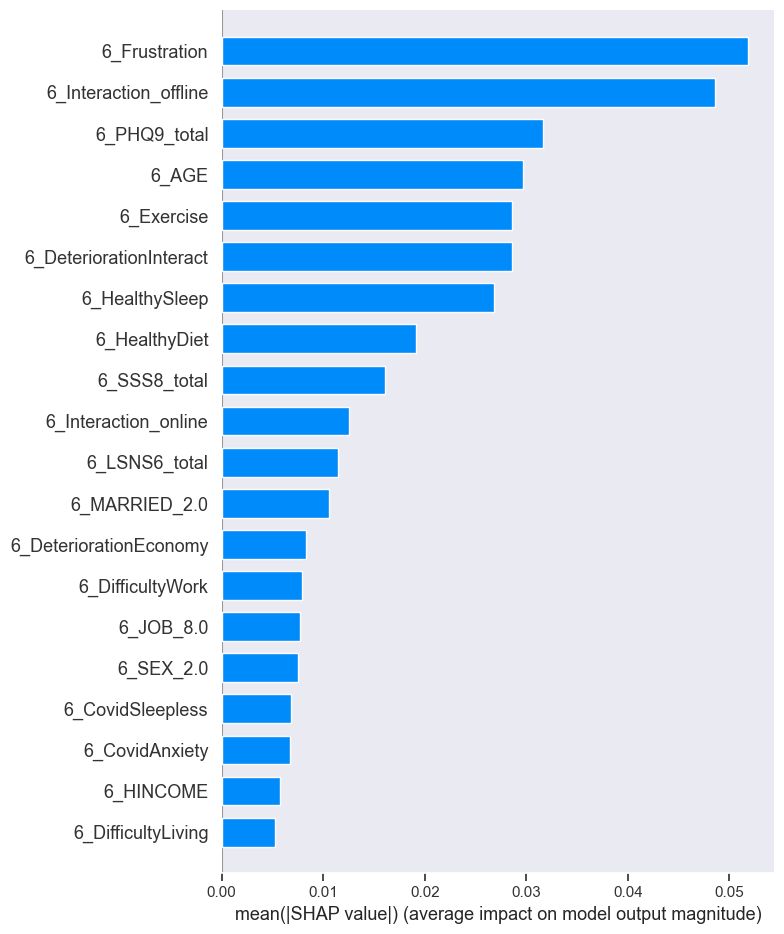

SHAP summary plot for class: Low


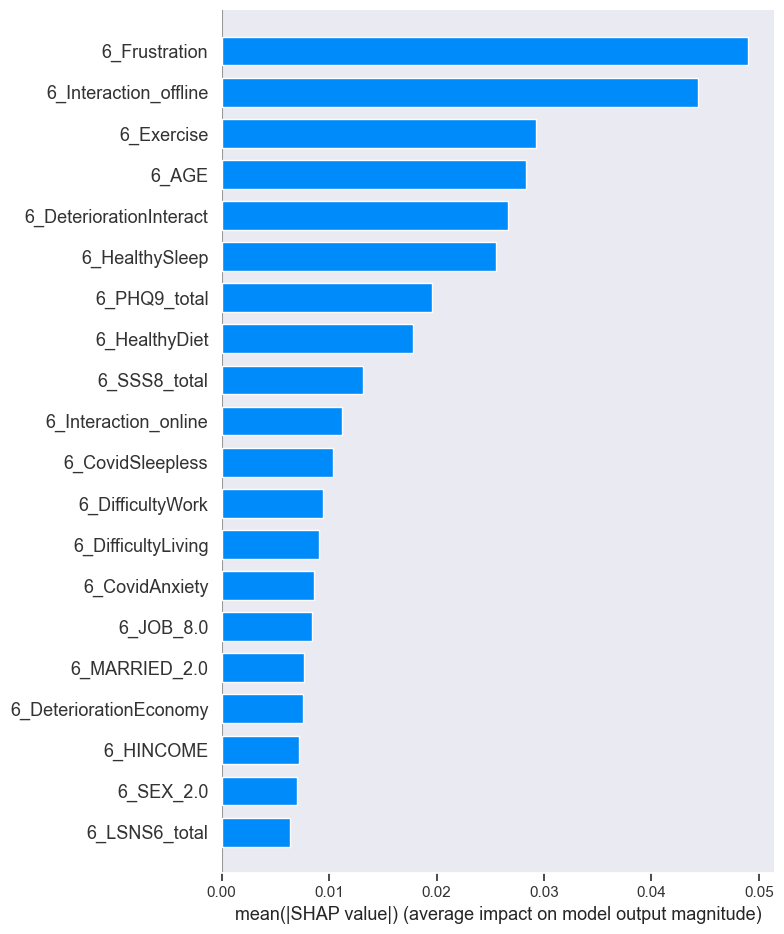

SHAP summary plot for class: Moderate


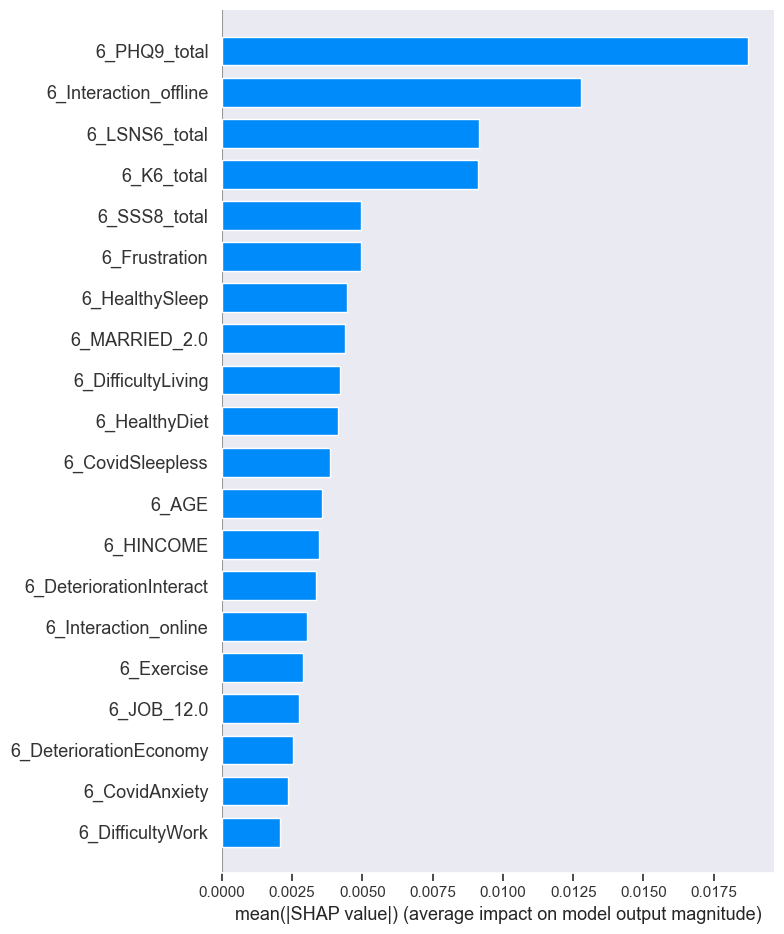

SHAP summary plot for class: Moderately high


IndexError: index 3 is out of bounds for axis 2 with size 3

In [59]:
# Plot SHAP values for each class without manually specifying `n`
for i, class_name in enumerate(class_names):
    print(f"SHAP summary plot for class: {class_name}")
    shap.summary_plot(shap_values[:, :, i], X_train, feature_names=features_list, plot_type="bar")

SHAP summary plot for class: Minimal loneliness


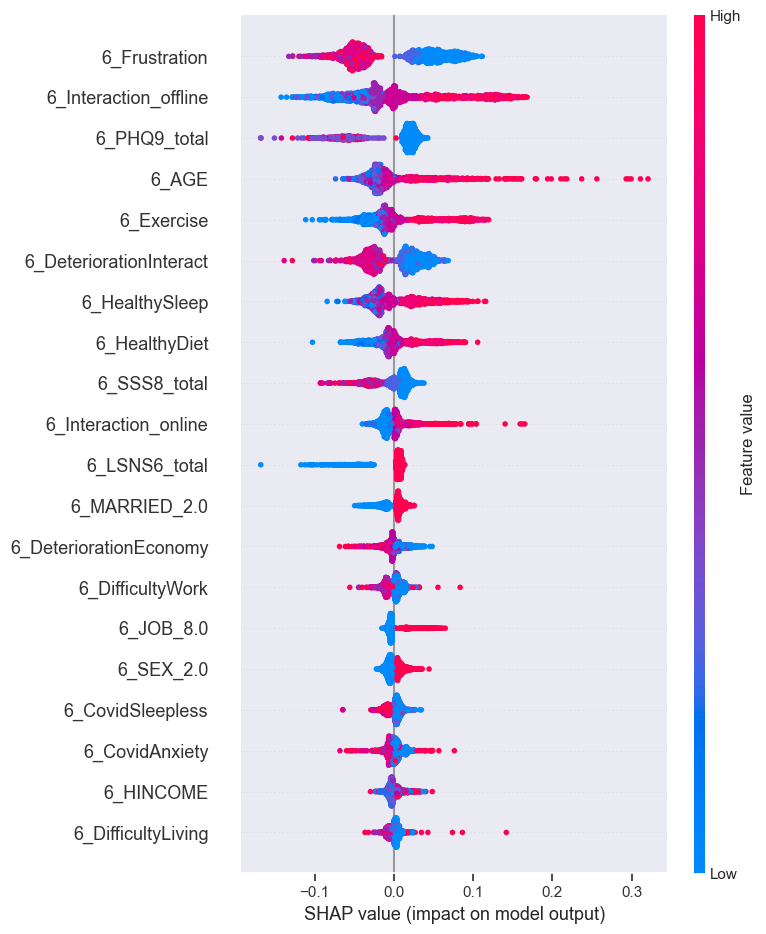

SHAP summary plot for class: Low


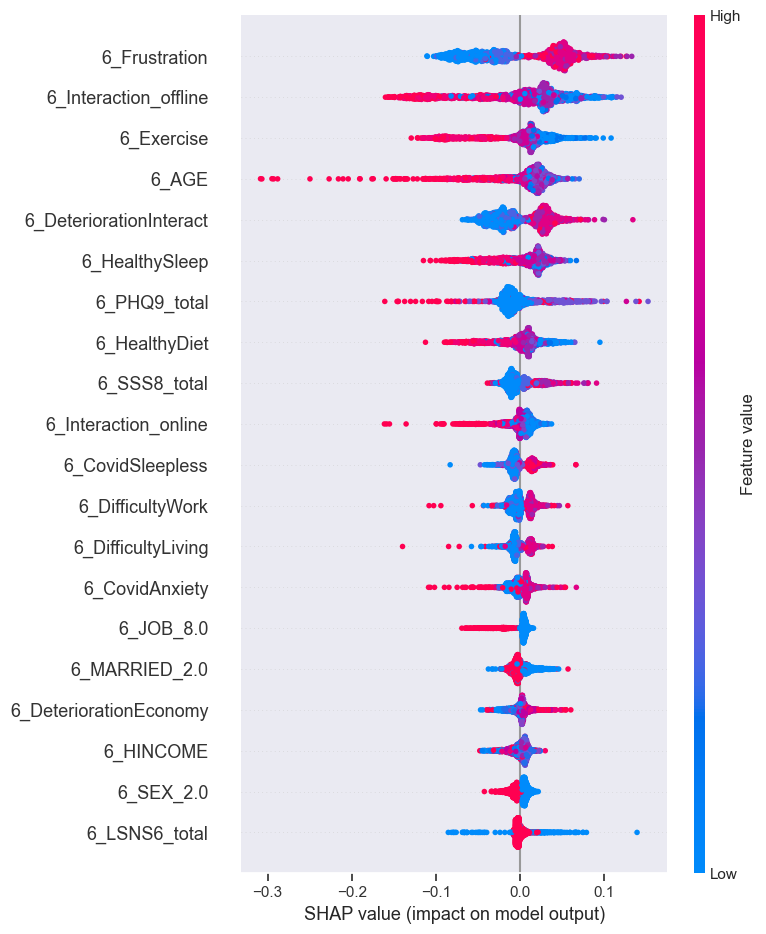

SHAP summary plot for class: Moderate


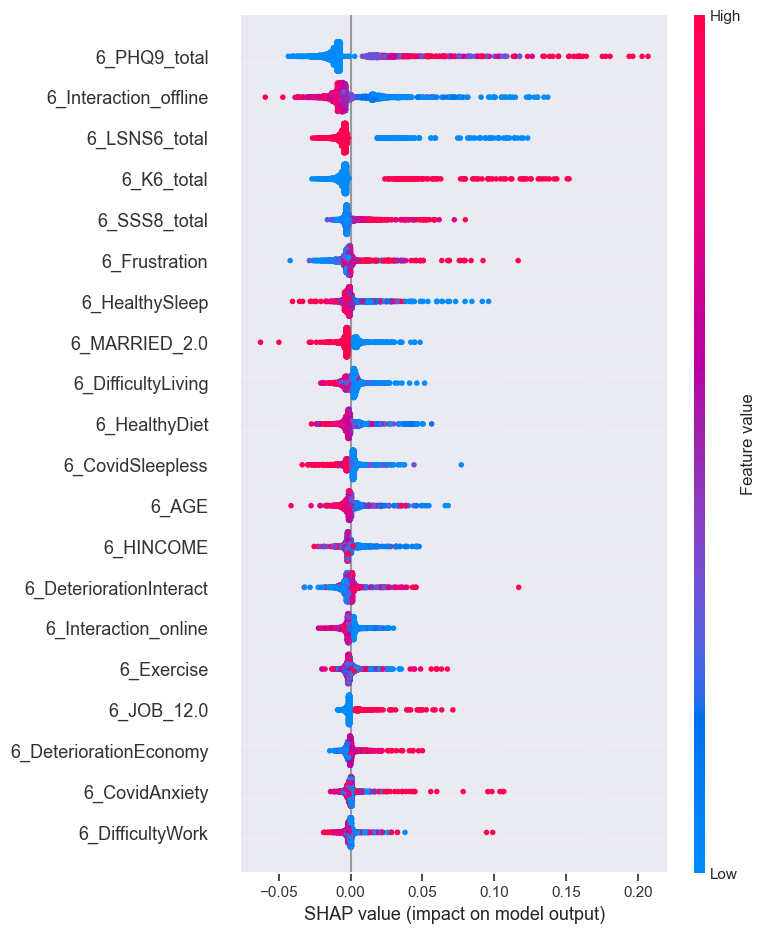

SHAP summary plot for class: Moderately high


IndexError: index 3 is out of bounds for axis 2 with size 3

In [60]:
# Feature Effects
for i, class_name in enumerate(class_names):
    print(f"SHAP summary plot for class: {class_name}")
    shap.summary_plot(shap_values[:, :, i], X_train, feature_names=features_list)

In [61]:
# Dependence
print('Interaction values')
shap_interaction_values = explainer.shap_interaction_values(X_test)
print(shap_interaction_values)

Interaction values
[[[[-2.09702662e-02  2.15121250e-02 -5.41858727e-04]
   [-4.94486334e-04  5.05205771e-04 -1.07194372e-05]
   [ 1.24417818e-03 -9.55435483e-04 -2.88742701e-04]
   ...
   [-1.19144740e-08  9.57893419e-09  2.33553980e-09]
   [-2.08012227e-05  2.38275922e-05 -3.02636946e-06]
   [-1.90723462e-04  2.90085043e-04 -9.93615811e-05]]

  [[-4.94486334e-04  5.05205771e-04 -1.07194372e-05]
   [-1.24133441e-03  4.39926977e-03 -3.15793536e-03]
   [ 1.22660998e-05 -9.91492596e-05  8.68831598e-05]
   ...
   [-1.76718299e-09  1.96681768e-09 -1.99634691e-10]
   [-5.15922117e-07  1.94121280e-06 -1.42529068e-06]
   [ 3.97582625e-06 -7.19044851e-05  6.79286589e-05]]

  [[ 1.24417818e-03 -9.55435483e-04 -2.88742701e-04]
   [ 1.22660998e-05 -9.91492596e-05  8.68831598e-05]
   [-5.67798915e-03  7.24197504e-03 -1.56398589e-03]
   ...
   [ 3.28043841e-08 -3.15011432e-08 -1.30324099e-09]
   [ 2.75721139e-05 -3.79004990e-05  1.03283851e-05]
   [-1.80898649e-06  1.79012896e-05 -1.60923031e-05]]



In [62]:
# Define a path for the interaction values
shap_interaction_values_test_path = "shap_interaction_values_test.pkl"

In [63]:
# Save the SHAP interaction values for the test data
with open(shap_interaction_values_test_path, "wb") as f:
    pickle.dump(shap_interaction_values, f)

In [64]:
# Load the SHAP interaction values for the test data
with open(shap_interaction_values_test_path, "rb") as f:
    shap_interaction_values = pickle.load(f)

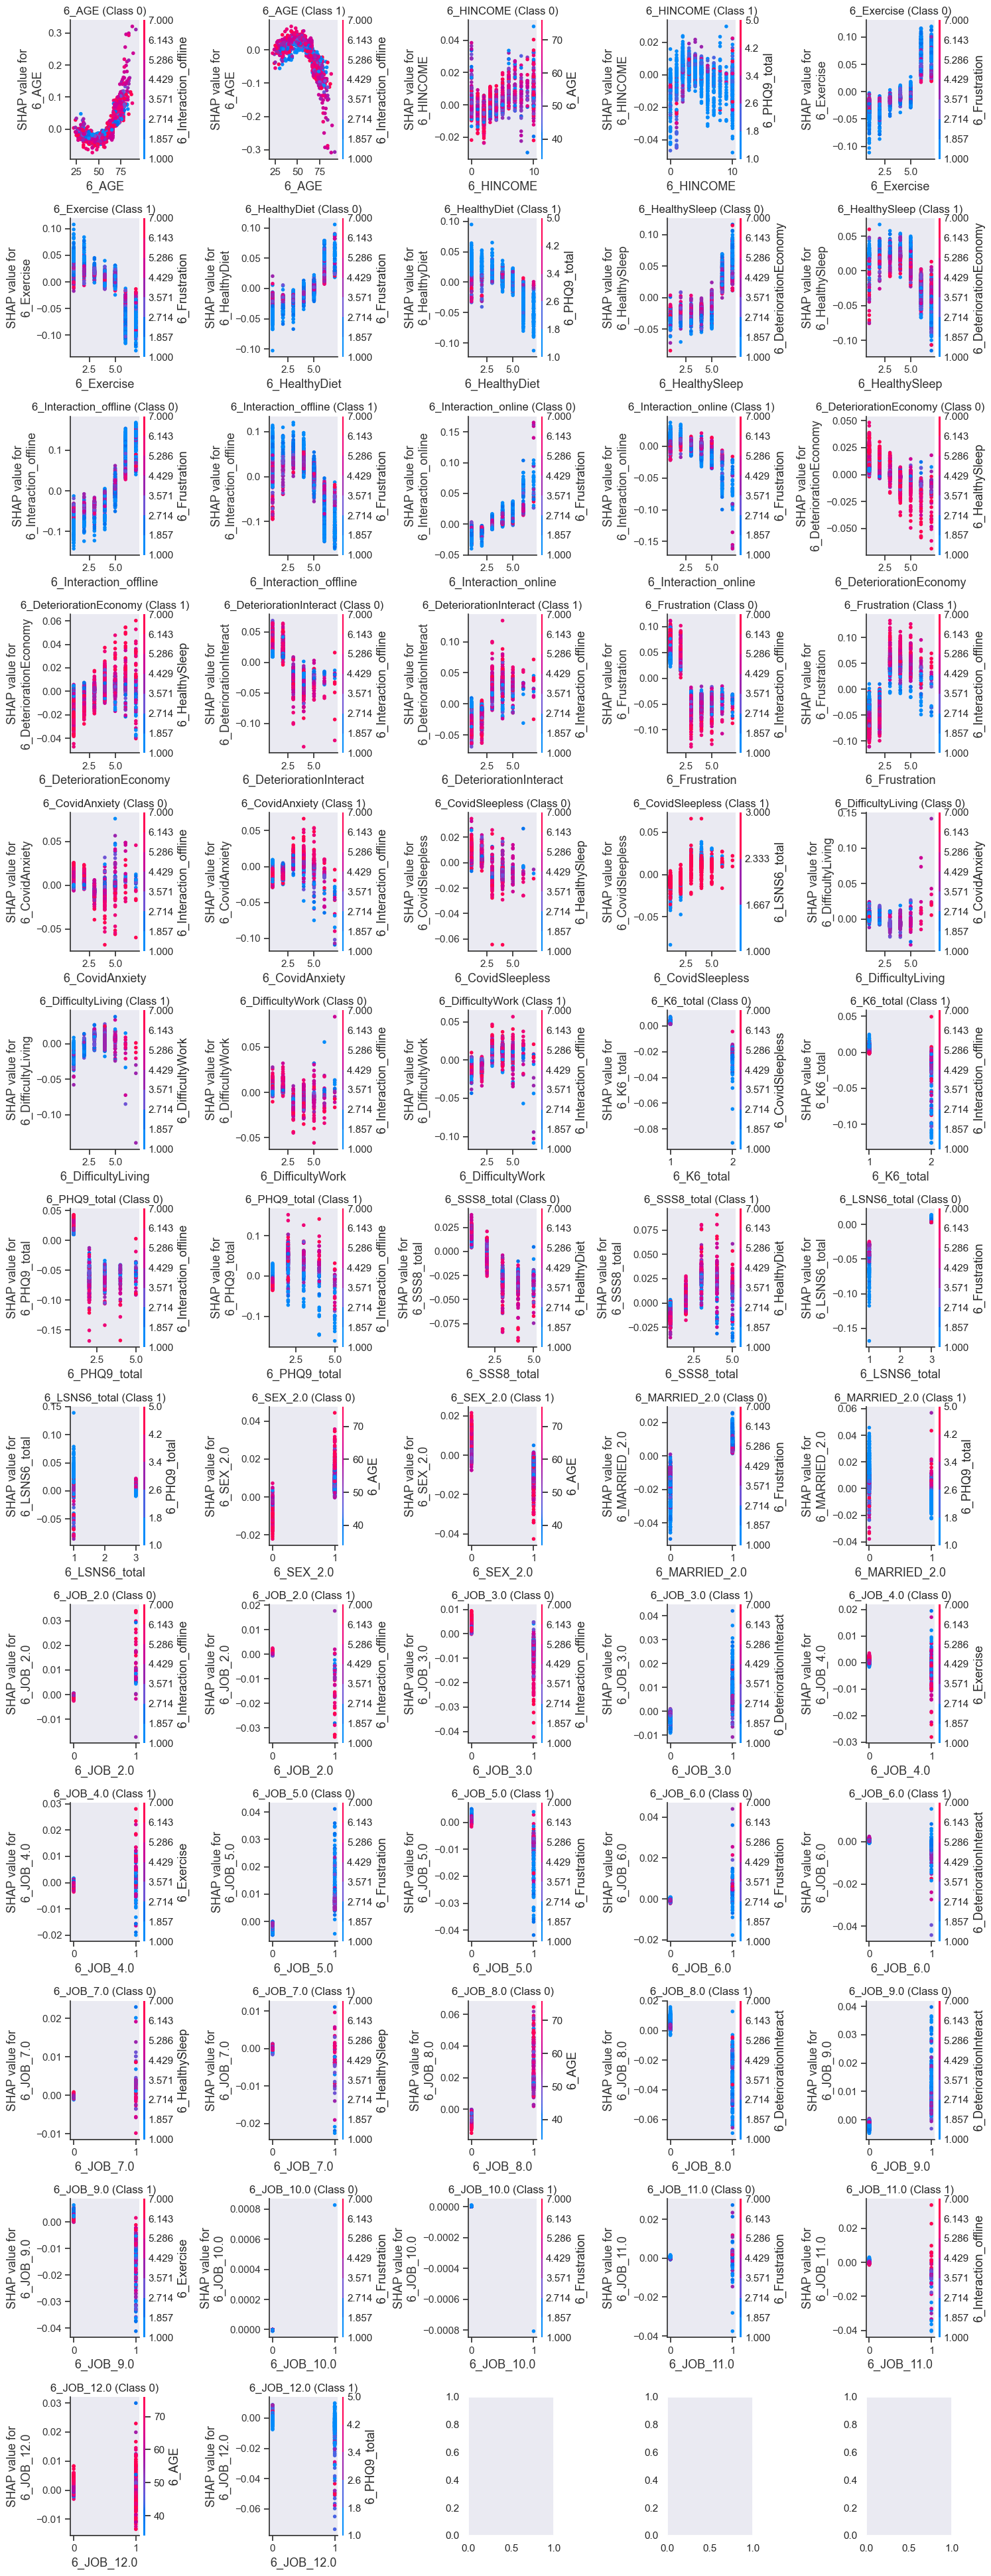

In [65]:
# Define number of rows and columns for the grid
n_features = len(features_list)
n_cols = len(class_names)
n_rows = (n_features * 2 + n_cols - 1) // n_cols  # 2 plots per feature (one for each class)

# Set up the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()  # Flatten to make indexing easier

# Loop over features to plot both classes
for idx, ft in enumerate(features_list):
    # Plot dependence for the first class
    shap.dependence_plot(
        ft, shap_values[:, :, 0], X_train, ax=axes[idx * 2], show=False
    )
    axes[idx * 2].set_title(f"{ft} (Class 0)")

    # Plot dependence for the second class
    shap.dependence_plot(
        ft, shap_values[:, :, 1], X_train, ax=axes[idx * 2 + 1], show=False
    )
    axes[idx * 2 + 1].set_title(f"{ft} (Class 1)")

# Adjust layout and display
plt.tight_layout()
plt.show()


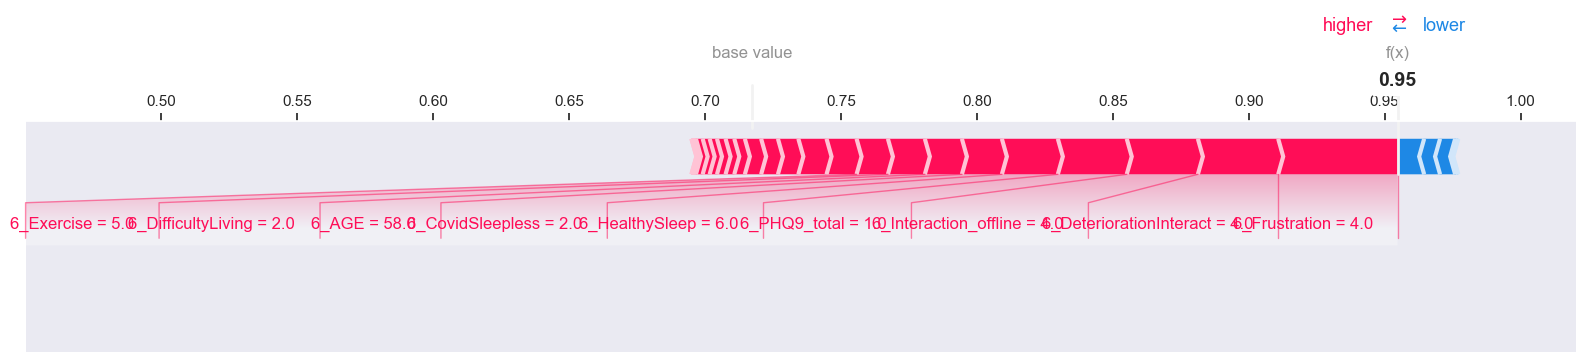

Sample: 6_AGE                       59.0
6_HINCOME                    1.0
6_Exercise                   4.0
6_HealthyDiet                4.0
6_HealthySleep               4.0
6_Interaction_offline        4.0
6_Interaction_online         4.0
6_DeteriorationEconomy       4.0
6_DeteriorationInteract      4.0
6_Frustration                4.0
6_CovidAnxiety               4.0
6_CovidSleepless             4.0
6_DifficultyLiving           4.0
6_DifficultyWork             4.0
6_K6_total                     1
6_PHQ9_total                   3
6_SSS8_total                   2
6_LSNS6_total                  3
6_SEX_2.0                   True
6_MARRIED_2.0              False
6_JOB_2.0                  False
6_JOB_3.0                  False
6_JOB_4.0                  False
6_JOB_5.0                  False
6_JOB_6.0                  False
6_JOB_7.0                  False
6_JOB_8.0                  False
6_JOB_9.0                   True
6_JOB_10.0                 False
6_JOB_11.0                 False
6_

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

In [66]:
# Additive Force
# Set sample index
i = 0  # Sample index

# Plot the force plot for the i-th sample and the second class
shap.force_plot(
    explainer.expected_value[1],  # Expected value for the second class
    shap_values[i, :, 1],         # SHAP values for the i-th sample, second class
    X_test.iloc[i],                # Features of the i-th sample
    feature_names=features_list,
    matplotlib=True
)

# Print sample details and SHAP values
print("Sample:", X_train.iloc[i])
print("\nSHAP Expected value for second class: %.2f" % explainer.expected_value[1])
print("Actual value: %.2f" % y_train.iloc[i])

# Extract the predicted value safely
predicted_value = tuned_model.predict(pd.DataFrame(X_train.iloc[i]).T)[0]  # Extract the first element
print("Predicted value: %.2f" % predicted_value)


# Local bar plot


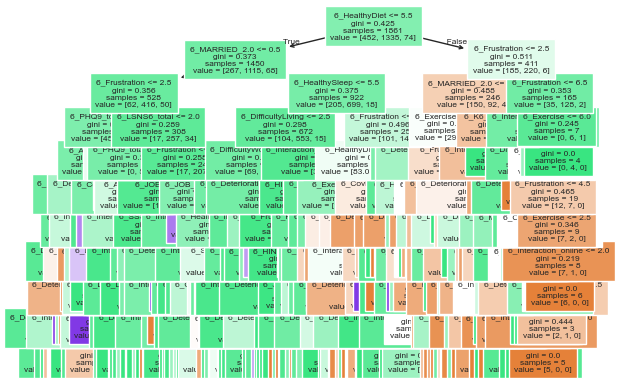

In [69]:
# Random Forest Visualization
# By Piotr Płoński
# https://mljar.com/blog/visualize-tree-from-random-forest/
import dtreeviz
from sklearn import tree

plt.figure()
tree.plot_tree(tuned_model.estimators_[0], feature_names=features_list, filled=True, fontsize=6)
plt.savefig('tree_high_dpi')

# Dashboard

In [53]:
#!pip install explainerdashboard
#!pip install -U explainerdashboard

In [48]:
from explainerdashboard import ClassifierExplainer, ExplainerDashboard
explainer = ClassifierExplainer(best_model, X_test, y_test, labels=labels)

from explainerdashboard import ExplainerDashboard
db = ExplainerDashboard(explainer,
                        # importances tab
                        importances=True,
                        hide_globalcutoff=True,
                        hide_cutoff=True,
                        
                        # model summary tab
                        model_summary=True,
                        
                        # contributions tab
                        contributions=True,
                        
                        # what if tab
                        whatif=True,
                        
                        # shap dependence tab
                        shap_dependenc=True,
                        
                        # tabs turned off
                        shap_interaction=False,
                        decision_trees=False)

Detected RandomForestClassifier model: Changing class type to RandomForestClassifierExplainer...
Note: model_output=='probability', so assuming that raw shap output of RandomForestClassifier is in probability space...
Generating self.shap_explainer = shap.TreeExplainer(model)
Building ExplainerDashboard..
Detected notebook environment, consider setting mode='external', mode='inline' or mode='jupyterlab' to keep the notebook interactive while the dashboard is running...
Generating layout...
Calculating shap values...
Calculating prediction probabilities...
Calculating metrics...
Calculating confusion matrices...
Calculating classification_dfs...
Calculating roc auc curves...
Calculating pr auc curves...
Calculating liftcurve_dfs...
Calculating dependencies...
Calculating permutation importances (if slow, try setting n_jobs parameter)...
Calculating predictions...
Calculating pred_percentiles...
Reminder: you can store the explainer (including calculated dependencies) with explainer.dump

In [49]:
db.run()

Starting ExplainerDashboard on http://10.13.9.107:8050


# Counterfactuals

https://github.com/andreArtelt/ceml

In [59]:
import dice_ml
from dice_ml.utils import helpers # helper functions
from sklearn.model_selection import train_test_split

dataset = helpers.load_adult_income_dataset()
target = dataset["income"] # outcome variable
train_dataset, test_dataset, _, _ = train_test_split(dataset,
                                                     target,
                                                     test_size=0.2,
                                                     random_state=0,
                                                     stratify=target)
# Dataset for training an ML model
d = dice_ml.Data(dataframe=train_dataset,
                 continuous_features=['age', 'hours_per_week'],
                 outcome_name='income')

# Pre-trained ML model
m = dice_ml.Model(model_path=dice_ml.utils.helpers.get_adult_income_modelpath(),
                  backend='TF2', func="ohe-min-max")
# DiCE explanation instance
exp = dice_ml.Dice(d,m)

ModuleNotFoundError: No module named 'dice_ml'